### import needed packages and read the combined dataset

In [1]:
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display
import re
from collections import Counter
import unicodedata

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
# Load the unified email dataset
email_df = pd.read_csv('datasets/processed/combined_dataset.csv', low_memory=False)

print(f"Total Records: {email_df.shape[0]:,}")
print(f"Total Features: {email_df.shape[1]}")
print(f"Memory Usage: {email_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumns:", list(email_df.columns))


Total Records: 114,578
Total Features: 8
Memory Usage: 304.20 MB

Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'source_dataset']


### We will deal with our data in this exact order
1. Label distribution - Understand class balance first (critical for phishing detection)
2. Duplicates - Remove exact/near duplicates early
3. Data quality issues - Invalid entries, malformed data, inconsistencies
4. Text-specific cleaning - Remove empty bodies, weird encoding, etc.
5. Missing data - Handle nulls LAST (after removing junk rows)

1. Label distribution - Understand class balance first (critical for phishing detection)


Overall Label Distribution:
Label 0: 50,260 (43.87%)
Label 1: 64,318 (56.13%)


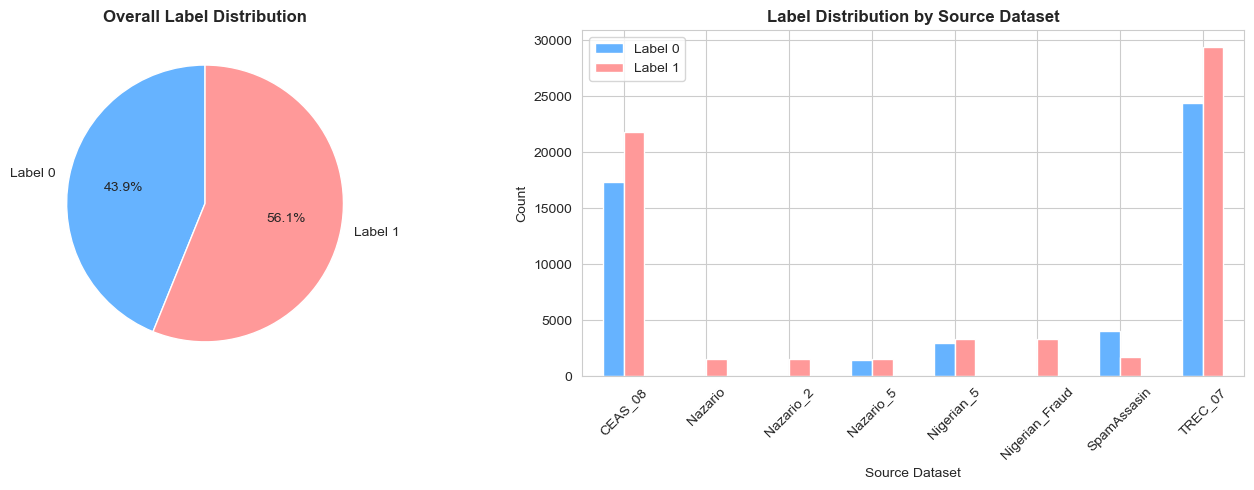

In [3]:
# Overall label distribution
label_counts = email_df['label'].value_counts().sort_index()
label_pct = (email_df['label'].value_counts(normalize=True).sort_index() * 100).round(2)

print("\nOverall Label Distribution:")
print(f"Label 0: {label_counts.get(0, 0):,} ({label_pct.get(0, 0)}%)")
print(f"Label 1: {label_counts.get(1, 0):,} ({label_pct.get(1, 0)}%)")

# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(label_counts, labels=[f'Label {i}' for i in label_counts.index],
            autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
axes[0].set_title('Overall Label Distribution', fontsize=12, fontweight='bold')

# Bar chart by source dataset
label_by_source = email_df.groupby(['source_dataset', 'label']).size().unstack(fill_value=0)
label_by_source.plot(kind='bar', ax=axes[1], color=['#66b3ff', '#ff9999'])
axes[1].set_title('Label Distribution by Source Dataset', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Source Dataset')
axes[1].set_ylabel('Count')
axes[1].legend(['Label 0', 'Label 1'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


#### Key Findings:
1. Reasonably balanced: 56.1% phishing (Label 1) vs 43.9% legitimate (Label 0)
2. CEAS_08 & TREC_07 dominate the dataset (largest bars)
3. Nazario variants are almost entirely phishing (Label 1)
4. Nigerian_Fraud is 100% phishing
5. Good mix across sources

2. Duplicates - Remove exact/near duplicates early


Exact Duplicates (all columns): 0 (0.00%)

Duplicates by Key Columns:
  body: 16660 (14.54%)
  subject: 75346 (65.76%)
  subject + body: 16659 (14.54%)
  sender + subject + body: 16658 (14.54%)

----------------------------------------------------------------------
Duplicate Distribution Across Sources:
----------------------------------------------------------------------
source_dataset
Nigerian_5        5592
Nigerian_Fraud    3332
Nazario_5         2804
Nazario           1565
Nazario_2         1565
TREC_07            601
CEAS_08            600
SpamAssasin        600
Name: count, dtype: int64


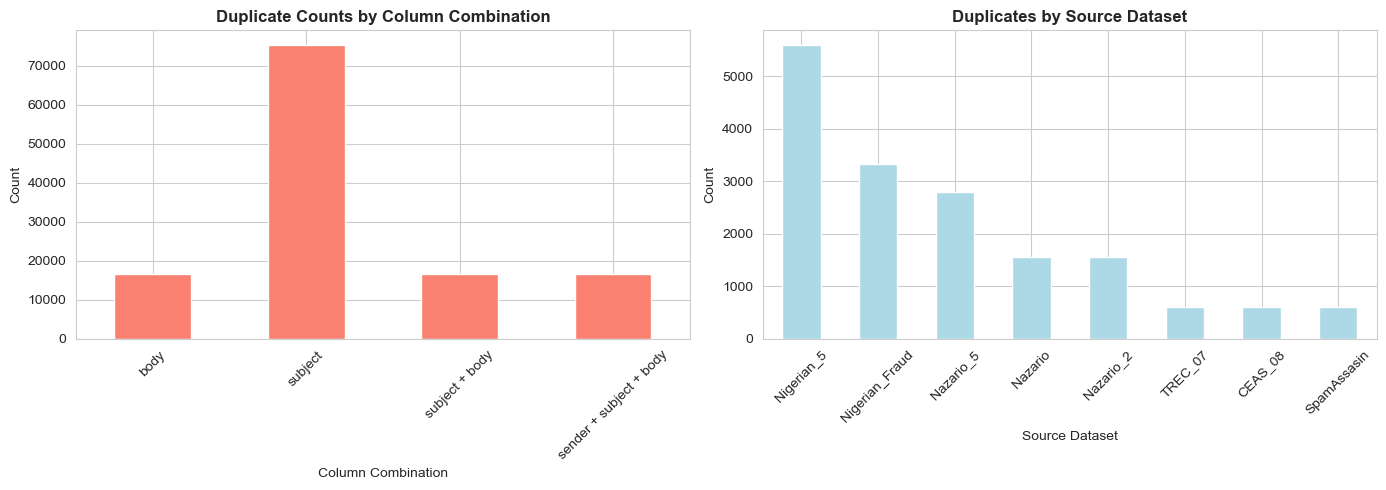


----------------------------------------------------------------------
Sample Duplicate Emails:
----------------------------------------------------------------------


,sender,subject,body,label,source_dataset
43352,Bruce D'Ambrosio <ykpbgoxj@cs.orst.edu>,[UAI] CfP: DATE05: Subtrack Real-time Systems,\t\t\t Call for Papers\n\t Subtrack on...,0,Nazario_5
427,Bruce D'Ambrosio <ykpbgoxj@cs.orst.edu>,[UAI] CfP: DATE05: Subtrack Real-time Systems,\t\t\t Call for Papers\n\t Subtrack on...,0,CEAS_08
50648,Bruce D'Ambrosio <ykpbgoxj@cs.orst.edu>,[UAI] CfP: DATE05: Subtrack Real-time Systems,\t\t\t Call for Papers\n\t Subtrack on...,0,Nigerian_5
50668,kmgxpj+iq@gatsby.ucl.ac.uk,[UAI] Three Faculty Positions in CS at Univers...,\t\t UNIVERSITY COLLEGE LONDON\n\n\t\t ...,0,Nigerian_5


In [4]:
# Exact duplicates (all columns)
exact_duplicates = email_df.duplicated().sum()
print(f"\nExact Duplicates (all columns): {exact_duplicates} ({exact_duplicates/len(email_df)*100:.2f}%)")

# Duplicates by key columns
duplicate_analysis = {
    'body': email_df.duplicated(subset=['body'], keep=False).sum(),
    'subject': email_df.duplicated(subset=['subject'], keep=False).sum(),
    'subject + body': email_df.duplicated(subset=['subject', 'body'], keep=False).sum(),
    'sender + subject + body': email_df.duplicated(subset=['sender', 'subject', 'body'], keep=False).sum()
}

print("\nDuplicates by Key Columns:")
for key, count in duplicate_analysis.items():
    print(f"  {key}: {count} ({count/len(email_df)*100:.2f}%)")

# Check if duplicates are in same or different source datasets
print("\n" + "-"*70)
print("Duplicate Distribution Across Sources:")
print("-"*70)

duplicate_mask = email_df.duplicated(subset=['subject', 'body'], keep=False)
duplicate_by_source = email_df[duplicate_mask]['source_dataset'].value_counts()
print(duplicate_by_source)

# Visualize duplicates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duplicate types
dup_data = pd.Series(duplicate_analysis)
dup_data.plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Duplicate Counts by Column Combination', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Column Combination')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Duplicates by source
duplicate_by_source.plot(kind='bar', ax=axes[1], color='lightblue')
axes[1].set_title('Duplicates by Source Dataset', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Source Dataset')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Sample duplicate content
print("\n" + "-"*70)
print("Sample Duplicate Emails:")
print("-"*70)
duplicate_bodies = email_df[email_df.duplicated(subset=['body'], keep=False)].sort_values('body')
if len(duplicate_bodies) > 0:
    sample_dup = duplicate_bodies.head(4)[['sender', 'subject', 'body', 'label', 'source_dataset']]
    display(sample_dup)


#### Key Findings:
1. No exact duplicates (0%) - good!
2. 16,660 duplicate bodies (14.54%) - significant!
3. 75,346 duplicate subjects (65.76%) - very high, but subjects can be generic
4. Nigerian datasets have most duplicates (Nigerian_5: 5,592, Nigerian_Fraud: 3,332)

### REMOVING TRUE DUPLICATES (sender + subject + body)
##### Why sender + subject + body is OPTIMAL:
* Truly identical emails - exact same sender, subject, content = zero new information
* Keeps legitimate variations (same content, different senders)
* Preserves diversity while removing actual duplicates
* This is the same email sent multiple times in the dataset

In [5]:
# Store original dimensions
original_rows = len(email_df)
original_cols = email_df.shape[1]

print(f"\nOriginal Dataset Dimensions:")
print(f"  Rows: {original_rows:,}")
print(f"  Columns: {original_cols}")
print(f"  Shape: {original_rows:,} × {original_cols}")

# Remove duplicates based on sender + subject + body
email_df = email_df.drop_duplicates(subset=['sender', 'subject', 'body'], keep='first')

# New dimensions
new_rows = len(email_df)
new_cols = email_df.shape[1]
removed = original_rows - new_rows

print(f"\nAfter Removing Duplicates:")
print(f"  Rows: {new_rows:,}")
print(f"  Columns: {new_cols}")
print(f"  Shape: {new_rows:,} × {new_cols}")

print(f"\nRemoved: {removed:,} duplicate emails ({removed/original_rows*100:.2f}%)")
print(f"Retained: {new_rows:,} unique emails ({new_rows/original_rows*100:.2f}%)")

# Check label distribution after deduplication
print("\n" + "-"*70)
print("Label Distribution After Deduplication:")
print("-"*70)
label_counts_new = email_df['label'].value_counts().sort_index()
for label, count in label_counts_new.items():
    pct = count/new_rows*100
    print(f"  Label {label}: {count:,} ({pct:.2f}%)")

# Memory usage
memory_mb = email_df.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory Usage: {memory_mb:.2f} MB")


Original Dataset Dimensions:
  Rows: 114,578
  Columns: 8
  Shape: 114,578 × 8

After Removing Duplicates:
  Rows: 105,077
  Columns: 8
  Shape: 105,077 × 8

Removed: 9,501 duplicate emails (8.29%)
Retained: 105,077 unique emails (91.71%)

----------------------------------------------------------------------
Label Distribution After Deduplication:
----------------------------------------------------------------------
  Label 0: 47,221 (44.94%)
  Label 1: 57,856 (55.06%)

Memory Usage: 259.54 MB


3. Data quality issues - Invalid entries, malformed data, inconsistencies

In [6]:
# 1. BASIC DATA OVERVIEW
print("\n" + "="*70)
print("1. BASIC DATA INFO")
print("="*70)
print(email_df.info())

# 2. MISSING VALUES ANALYSIS
print("\n" + "="*70)
print("2. MISSING VALUES")
print("="*70)
missing_data = pd.DataFrame({
    'Column': email_df.columns,
    'Missing_Count': email_df.isnull().sum(),
    'Missing_Percentage': (email_df.isnull().sum() / len(email_df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data.to_string(index=False))

# 3. DATA TYPE CONSISTENCY
print("\n" + "="*70)
print("3. DATA TYPE ANALYSIS")
print("="*70)
print(email_df.dtypes)

# Check if 'urls' column has consistent type across all rows
print(f"\nURLs column unique data types: {email_df['urls'].apply(type).unique()}")

# 4. LABEL VALUES CHECK
print("\n" + "="*70)
print("4. LABEL VALUES CHECK")
print("="*70)
print("Unique label values:", email_df['label'].unique())
print("Label value counts:")
print(email_df['label'].value_counts().sort_index())

# Check for any non-binary labels
invalid_labels = email_df[~email_df['label'].isin([0, 1])]
print(f"\nInvalid labels (not 0 or 1): {len(invalid_labels)}")

# 5. EMAIL ADDRESS FORMAT CHECK
print("\n" + "="*70)
print("5. EMAIL ADDRESS FORMAT CHECK")
print("="*70)

# Simple email pattern
email_pattern = r'^[^@\s]+@[^@\s]+\.[^@\s]+$'

# Check sender
invalid_senders = email_df[email_df['sender'].notna() & ~email_df['sender'].str.match(email_pattern, na=False)]
print(f"Invalid sender format: {len(invalid_senders):,} ({len(invalid_senders)/len(email_df)*100:.2f}%)")
if len(invalid_senders) > 0:
    print("\nSample invalid senders:")
    print(invalid_senders['sender'].head(10).tolist())

# Check receiver
invalid_receivers = email_df[email_df['receiver'].notna() & ~email_df['receiver'].str.match(email_pattern, na=False)]
print(f"\nInvalid receiver format: {len(invalid_receivers):,} ({len(invalid_receivers)/len(email_df)*100:.2f}%)")
if len(invalid_receivers) > 0:
    print("\nSample invalid receivers:")
    print(invalid_receivers['receiver'].head(10).tolist())

# 6. TEXT FIELD QUALITY
print("\n" + "="*70)
print("6. TEXT FIELD QUALITY")
print("="*70)

# Check for empty or whitespace-only fields
empty_subjects = email_df[email_df['subject'].isna() | (email_df['subject'].str.strip() == '')]
print(f"Empty/whitespace subjects: {len(empty_subjects):,} ({len(empty_subjects)/len(email_df)*100:.2f}%)")

empty_bodies = email_df[email_df['body'].isna() | (email_df['body'].str.strip() == '')]
print(f"Empty/whitespace bodies: {len(empty_bodies):,} ({len(empty_bodies)/len(email_df)*100:.2f}%)")

# Check body length distribution
email_df['body_length'] = email_df['body'].fillna('').str.len()
print(f"\nBody length statistics:")
print(email_df['body_length'].describe())

# Very short bodies (potential data quality issues)
very_short_bodies = email_df[email_df['body_length'] < 10]
print(f"\nVery short bodies (<10 chars): {len(very_short_bodies):,} ({len(very_short_bodies)/len(email_df)*100:.2f}%)")
if len(very_short_bodies) > 0:
    print("\nSample very short bodies:")
    print(very_short_bodies[['subject', 'body', 'label']].head(5))

# 7. DATE FORMAT CHECK
print("\n" + "="*70)
print("7. DATE FORMAT CHECK")
print("="*70)
print(f"Date column data type: {email_df['date'].dtype}")
print(f"\nSample date values:")
print(email_df['date'].dropna().head(10).tolist())

# Check for non-parseable dates
def is_valid_date(date_str):
    if pd.isna(date_str):
        return False
    try:
        pd.to_datetime(date_str)
        return True
    except:
        return False

date_validity = email_df['date'].apply(is_valid_date)
invalid_dates = email_df[~date_validity & email_df['date'].notna()]
print(f"\nInvalid date formats: {len(invalid_dates):,}")
if len(invalid_dates) > 0:
    print("\nSample invalid dates:")
    print(invalid_dates['date'].head(10).tolist())

# 8. SPECIAL CHARACTERS / ENCODING ISSUES
print("\n" + "="*70)
print("8. ENCODING ISSUES CHECK")
print("="*70)

# Check for common encoding artifacts
encoding_patterns = [r'\x00', r'�', r'\\x[0-9a-f]{2}', r'&nbsp;', r'&lt;', r'&gt;']
encoding_issues = email_df['body'].str.contains('|'.join(encoding_patterns), case=False, na=False).sum()
print(f"Emails with potential encoding issues: {encoding_issues:,} ({encoding_issues/len(email_df)*100:.2f}%)")

# Sample with encoding issues
if encoding_issues > 0:
    sample_encoding = email_df[email_df['body'].str.contains('|'.join(encoding_patterns), case=False, na=False)].head(3)
    print("\nSample bodies with encoding issues:")
    for idx, row in sample_encoding.iterrows():
        print(f"\n{row['body'][:200]}...")

# 9. DUPLICATE COLUMN VALUES (sanity check)
print("\n" + "="*70)
print("9. UNIQUENESS CHECK")
print("="*70)
for col in ['sender', 'receiver', 'subject', 'body']:
    unique_count = email_df[col].nunique()
    print(f"{col}: {unique_count:,} unique values ({unique_count/len(email_df)*100:.2f}%)")

print("\n" + "="*70)
print("DATA QUALITY EXPLORATION COMPLETE")
print("="*70)


1. BASIC DATA INFO
<class 'pandas.DataFrame'>
Index: 105077 entries, 0 to 114577
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   sender          104738 non-null  str  
 1   receiver        102645 non-null  str  
 2   date            104562 non-null  str  
 3   subject         104467 non-null  str  
 4   body            105076 non-null  str  
 5   label           105077 non-null  int64
 6   urls            105077 non-null  str  
 7   source_dataset  105077 non-null  str  
dtypes: int64(1), str(7)
memory usage: 7.2 MB
None

2. MISSING VALUES
  Column  Missing_Count  Missing_Percentage
receiver           2432                2.31
 subject            610                0.58
    date            515                0.49
  sender            339                0.32
    body              1                0.00

3. DATA TYPE ANALYSIS
sender              str
receiver            str
date                str
subject          

#### KEY FINDINGS & ACTIONS:
1. EMAIL FORMAT "ISSUES" - NO ACTION NEEDED
91% "invalid" senders, 29% "invalid" receivers
Reality: These are VALID - they include display names like "John Doe <john@email.com>"

3. DATA TYPE INCONSISTENCY
URLs column has mixed types: string AND int

4. INVALID/USELESS BODIES
19 emails with <10 character bodies (dots, spaces, useless)
5 completely empty bodies

5. ENCODING ISSUES
3,421 emails (3.26%) with encoding artifacts (�, HTML entities, etc.)

6. DATE FORMATS
336 invalid dates with garbled timezone data

7. EXTREME BODY LENGTH - INVESTIGATE
Max body: 4.6 MILLION characters! (likely data corruption)


### DATA QUALITY CLEANING

In [7]:
# Store original count
original_count = len(email_df)
print(f"\nStarting with: {original_count:,} emails\n")


Starting with: 105,077 emails



In [8]:
# 1. FIX URLs DATA TYPE INCONSISTENCY
print(f"Before: {email_df['urls'].apply(type).unique()}")
email_df['urls'] = email_df['urls'].astype(bool)
print(f"After: {email_df['urls'].apply(type).unique()}")
print("✓ URLs column converted to bool\n")

Before: [<class 'str'>]
After: [<class 'bool'>]
✓ URLs column converted to bool



In [9]:
# 2. REMOVE USELESS BODIES (<10 chars or empty)print("="*70)
print("2. REMOVING USELESS BODIES")
print("="*70)

# Identify useless bodies
useless_bodies = email_df[
    (email_df['body'].isna()) |
    (email_df['body'].str.strip().str.len() < 10)
]

print(f"Emails with useless bodies: {len(useless_bodies):,}")
print("\nSample useless bodies being removed:")
print(useless_bodies[['subject', 'body', 'label']].head())

# Remove useless bodies
email_df = email_df[
    (email_df['body'].notna()) &
    (email_df['body'].str.strip().str.len() >= 10)
]

removed_useless = original_count - len(email_df)
print(f"\n✓ Removed {removed_useless:,} emails with useless bodies")
print(f"Remaining: {len(email_df):,} emails\n")

2. REMOVING USELESS BODIES
Emails with useless bodies: 25

Sample useless bodies being removed:
                                                 subject   body  label
39200  Your USAA Checking Account Untrusted Authoriza...      .      1
39260          PLS READ THE NEW USAA NEW YEAR UPDATE NOW     \n      1
39602              USAA Electronic Wire Transfer Message    . .      1
39705                  https://hurinet.or.ug/webapp/, ,       1      1
40059                   Your Account Profile Has Expired  .. ..      1

✓ Removed 25 emails with useless bodies
Remaining: 105,052 emails



In [10]:
# 3. CLEAN ENCODING ISSUES
# Count before cleaning
encoding_before = email_df['body'].str.contains('�', na=False).sum()
print(f"Emails with '�' character: {encoding_before:,}")

# Clean common encoding issues
def clean_encoding(text):
    if pd.isna(text):
        return text

    # Replace common encoding artifacts
    text = text.replace('�', ' ')  # Replace replacement character
    text = text.replace('&nbsp;', ' ')  # HTML non-breaking space
    text = text.replace('&lt;', '<')  # HTML less than
    text = text.replace('&gt;', '>')  # HTML greater than
    text = text.replace('&amp;', '&')  # HTML ampersand
    text = text.replace('&quot;', '"')  # HTML quote

    # Remove null bytes
    text = text.replace('\x00', '')

    # Normalize whitespace
    text = ' '.join(text.split())

    return text

# Apply cleaning to body and subject
email_df['body'] = email_df['body'].apply(clean_encoding)
email_df['subject'] = email_df['subject'].apply(clean_encoding)

# Count after cleaning
encoding_after = email_df['body'].str.contains('�', na=False).sum()
print(f"After cleaning - Emails with '�': {encoding_after:,}")
print(f"✓ Cleaned encoding issues in {encoding_before - encoding_after:,} emails\n")

Emails with '�' character: 3,303
After cleaning - Emails with '�': 0
✓ Cleaned encoding issues in 3,303 emails



In [11]:
# 4. FIX INVALID DATES
# Function to safely parse dates
def safe_parse_date(date_str):
    if pd.isna(date_str):
        return pd.NaT
    try:
        return pd.to_datetime(date_str)
    except:
        return pd.NaT

# Count invalid dates before
invalid_before = email_df['date'].apply(lambda x: pd.isna(safe_parse_date(x))).sum()
print(f"Invalid dates before: {invalid_before:,}")

# Parse dates and set invalid to NaT
email_df['date'] = email_df['date'].apply(safe_parse_date)

# Count invalid dates after (now NaT)
invalid_after = email_df['date'].isna().sum()
print(f"Invalid dates after (set to NaT): {invalid_after:,}")
print(f"✓ Converted date column to datetime, {invalid_after:,} invalid dates set to NaT\n")

Invalid dates before: 826
Invalid dates after (set to NaT): 826
✓ Converted date column to datetime, 826 invalid dates set to NaT



In [12]:
# 5. INVESTIGATE EXTREME BODY LENGTH
# Recalculate body length after removing useless bodies
email_df['body_length'] = email_df['body'].str.len()

print("\nBody Length Statistics:")
print(email_df['body_length'].describe())

# Find extreme outliers
print("\nTop 10 Longest Bodies:")
longest_bodies = email_df.nlargest(10, 'body_length')[['subject', 'body_length', 'label', 'source_dataset']]
print(longest_bodies)

# Check distribution of very long bodies
very_long = email_df[email_df['body_length'] > 100000]
print(f"\n✓ Emails with body length > 100,000 chars: {len(very_long):,}")
if len(very_long) > 0:
    print("\nDistribution by label:")
    print(very_long['label'].value_counts())
    print("\nDistribution by source:")
    print(very_long['source_dataset'].value_counts())

    # Sample content from extremely long body
    print("\n" + "-"*70)
    print("Sample from longest body (first 500 chars):")
    print("-"*70)
    longest_idx = email_df['body_length'].idxmax()
    print(f"Subject: {email_df.loc[longest_idx, 'subject']}")
    print(f"Length: {email_df.loc[longest_idx, 'body_length']:,} characters")
    print(f"Label: {email_df.loc[longest_idx, 'label']}")
    print(f"\nBody preview:\n{email_df.loc[longest_idx, 'body'][:500]}...")



Body Length Statistics:
count    105052.00
mean       1700.31
std       15198.70
min           8.00
25%         382.00
50%         811.00
75%        1826.00
max     4560709.00
Name: body_length, dtype: float64

Top 10 Longest Bodies:
                                                 subject  body_length  label  \
39154  DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA      4560709      1   
39687                          someone has your password      1023577      1   
46525                           Line Separator Character       778816      0   
96844    [PATCH 1/2] Commit generated prototype headers.       641682      0   
59050  =?iso-2022-jp?B?GyRCRnxLXDhsJE43b0w+IUolNSVWJT...       299197      0   
46385                      I don't know why this is.<br>       277016      0   
59415            May I have a moment of your Time PLEASE       230849      1   
59387  =?big5?Q?=A7K=B6O=B5L=AD=AD=A6=B8=A5=F4=A5=B4=...       184159      1   
59067                        updated weblogs 

#### Key Findings:

* Only 23 emails (0.02%) are extremely long
* Mix of labels (15 legit, 8 phishing)
* Mostly from TREC_07 (10) and SpamAssassin (6)
* These are likely mail system artifacts or batch exports

COMBINED CLEANING: IQR 2.0 + SPECIFIC CORRUPTION PATTERNS

In [13]:
# Calculate body lengths first for analysis
email_df['body_length'] = email_df['body'].str.len()
original_count = len(email_df)
print(f"\nStarting with: {original_count:,} emails")


Starting with: 105,052 emails


In [14]:
# STEP 1: REMOVE STATISTICAL OUTLIERS USING IQR (MULTIPLIER 2.0)
# Calculate IQR
Q1 = email_df['body_length'].quantile(0.25)
Q3 = email_df['body_length'].quantile(0.75)
IQR = Q3 - Q1

# Use multiplier of 2.0 for aggressive outlier removal
multiplier = 2.0
upper_bound = Q3 + (multiplier * IQR)

print(f"\nIQR Statistics:")
print(f"  Q1 (25th percentile): {Q1:,.0f} characters")
print(f"  Q3 (75th percentile): {Q3:,.0f} characters")
print(f"  IQR: {IQR:,.0f} characters")
print(f"  Multiplier: {multiplier}")
print(f"  Upper Bound: {upper_bound:,.0f} characters")

# Identify IQR outliers
iqr_outliers = email_df[email_df['body_length'] > upper_bound]
print(f"\n✓ IQR outliers detected: {len(iqr_outliers):,} ({len(iqr_outliers)/len(email_df)*100:.3f}%)")

# Show sample IQR outliers
print("\nSample IQR outliers (Top 3 longest):")
for idx, row in iqr_outliers.nlargest(3, 'body_length').iterrows():
    print(f"  - Subject: {row['subject'][:60]}... | Length: {row['body_length']:,} | Label: {row['label']}")

# Remove IQR outliers
email_df = email_df[email_df['body_length'] <= upper_bound]
iqr_removed = original_count - len(email_df)

print(f"\nRemoved {iqr_removed:,} IQR outliers")
print(f"Remaining: {len(email_df):,} emails")


IQR Statistics:
  Q1 (25th percentile): 382 characters
  Q3 (75th percentile): 1,826 characters
  IQR: 1,444 characters
  Multiplier: 2.0
  Upper Bound: 4,714 characters

✓ IQR outliers detected: 5,013 (4.772%)

Sample IQR outliers (Top 3 longest):
  - Subject: DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA... | Length: 4,560,709 | Label: 1
  - Subject: someone has your password... | Length: 1,023,577 | Label: 1
  - Subject: Line Separator Character... | Length: 778,816 | Label: 0

Removed 5,013 IQR outliers
Remaining: 100,039 emails


In [15]:
# STEP 2: REMOVE SPECIFIC CORRUPTION PATTERNS
before_pattern_removal = len(email_df)

# 1. Remove mail folder metadata corruption
metadata_corruption = email_df['subject'].str.contains(
    "DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA",
    case=False,
    na=False
)

# 2. Remove emails that are clearly concatenated mail dumps (multiple "From:" headers pattern)
mail_dump_pattern = email_df['body'].str.count(r'From [0-9]+@').fillna(0) > 5

# 3. Alternative mail dump detection: multiple "Return-Path:" headers
return_path_dumps = email_df['body'].str.count(r'Return-Path:').fillna(0) > 5

# Combine all corruption conditions
corrupted = metadata_corruption | mail_dump_pattern | return_path_dumps

print(f"\nCorrupted emails detected by type:")
print(f"  1. Mail folder metadata: {metadata_corruption.sum():,}")
print(f"  2. Mail dumps (5+ 'From' patterns): {mail_dump_pattern.sum():,}")
print(f"  3. Mail dumps (5+ 'Return-Path'): {return_path_dumps.sum():,}")
print(f"  {'='*50}")
print(f"  Total unique corrupted emails: {corrupted.sum():,} ({corrupted.sum()/len(email_df)*100:.3f}%)")

# Show corrupted emails if any
if corrupted.sum() > 0:
    corrupted_emails = email_df[corrupted].copy()
    corrupted_emails = corrupted_emails.sort_values('body_length', ascending=False)

    print("\nTop 3 corrupted emails being removed:")
    for i, (idx, row) in enumerate(corrupted_emails.head(3).iterrows(), 1):
        print(f"\n  {i}. Subject: {row['subject'][:60]}...")
        print(f"     Length: {row['body_length']:,} | Label: {row['label']} | Source: {row['source_dataset']}")
        print(f"     Preview: {row['body'][:150]}...")

# Remove corrupted emails
email_df = email_df[~corrupted]
pattern_removed = before_pattern_removal - len(email_df)

print(f"\nRemoved {pattern_removed:,} corrupted emails")
print(f"Remaining: {len(email_df):,} emails")

# Drop temporary body_length column
email_df = email_df.drop('body_length', axis=1)


Corrupted emails detected by type:
  1. Mail folder metadata: 1
  2. Mail dumps (5+ 'From' patterns): 0
  3. Mail dumps (5+ 'Return-Path'): 0
  Total unique corrupted emails: 1 (0.001%)

Top 3 corrupted emails being removed:

  1. Subject: DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA...
     Length: 258 | Label: 1 | Source: Nazario
     Preview: This text is part of the internal format of your mail folder, and is not a real message. It is created automatically by the mail system software. If d...

Removed 1 corrupted emails
Remaining: 100,038 emails


# FINAL DATASET INFORMATION

In [16]:
print(f"\nDimensions: {email_df.shape[0]:,} rows × {email_df.shape[1]} columns")
print(f"Memory Usage: {email_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nColumns:")
for i, col in enumerate(email_df.columns, 1):
    print(f"  {i}. {col}")



Dimensions: 100,038 rows × 8 columns
Memory Usage: 165.83 MB

Columns:
  1. sender
  2. receiver
  3. date
  4. subject
  5. body
  6. label
  7. urls
  8. source_dataset


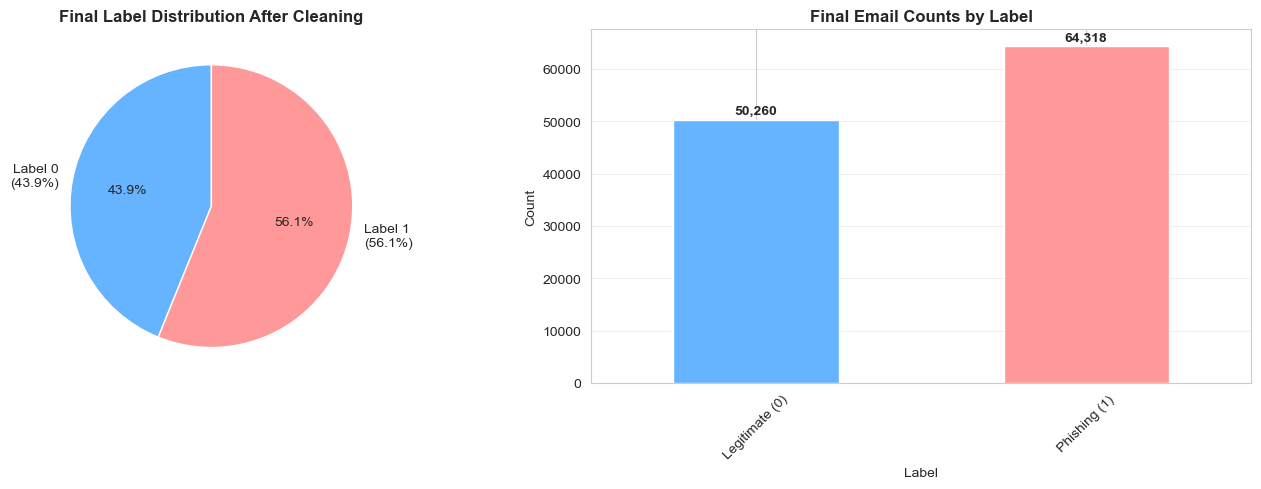

In [17]:
# VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(label_counts, labels=[f'Label {i}\n({label_pct[i]:.1f}%)' for i in label_counts.index],
            autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
axes[0].set_title('Final Label Distribution After Cleaning', fontsize=12, fontweight='bold')

# Bar chart
label_counts.plot(kind='bar', ax=axes[1], color=['#66b3ff', '#ff9999'])
axes[1].set_title('Final Email Counts by Label', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Legitimate (0)', 'Phishing (1)'], rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, (label, count) in enumerate(label_counts.items()):
    axes[1].text(i, count + 500, f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### INVESTIGATING REMAINING EMAIL BODY LENGTHS
* Lets re investigate all the emails with big body lengt

In [18]:
# Calculate body lengths
email_df['body_length'] = email_df['body'].str.len()

# Overall statistics
print("\nBody Length Statistics:")
print(email_df['body_length'].describe())

print(f"\nMin body length: {email_df['body_length'].min():,} characters")
print(f"Max body length: {email_df['body_length'].max():,} characters")
print(f"Mean body length: {email_df['body_length'].mean():,.2f} characters")
print(f"Median body length: {email_df['body_length'].median():,} characters")


Body Length Statistics:
count   100038.00
mean      1159.79
std       1070.19
min          8.00
25%        357.00
50%        768.00
75%       1634.00
max       4714.00
Name: body_length, dtype: float64

Min body length: 8 characters
Max body length: 4,714 characters
Mean body length: 1,159.79 characters
Median body length: 768.0 characters


### TOP AND BOTTOM 5 LONGEST EMAILS REMAINING

In [19]:
print("\n" + "="*70)
print("TOP 5 LONGEST EMAILS REMAINING IN DATASET:")
print("="*70)

longest_emails = email_df.nlargest(5, 'body_length')

for i, (idx, row) in enumerate(longest_emails.iterrows(), 1):
    print(f"\n{'-'*70}")
    print(f"Rank: #{i}")
    print(f"Subject: {row['subject']}")
    print(f"Body Length: {row['body_length']:,} characters")
    print(f"Label: {row['label']} ({'Phishing' if row['label'] == 1 else 'Legitimate'})")
    print(f"Source: {row['source_dataset']}")
    print(f"Sender: {row['sender']}")
    print(f"\nBody Preview (first 500 chars):")
    print(row['body'][:500] + "...")
    print(f"\nBody Preview (last 200 chars):")
    print("..." + row['body'][-200:])

print("\n" + "="*70)
print("BOTTOM 5 SHORTEST EMAILS REMAINING IN DATASET:")
print("="*70)

shortest_emails = email_df.nsmallest(5, 'body_length')

for i, (idx, row) in enumerate(shortest_emails.iterrows(), 1):
    print(f"\n{'-'*70}")
    print(f"Rank: #{i}")
    print(f"Subject: {row['subject']}")
    print(f"Body Length: {row['body_length']:,} characters")
    print(f"Label: {row['label']} ({'Phishing' if row['label'] == 1 else 'Legitimate'})")
    print(f"Source: {row['source_dataset']}")
    print(f"Sender: {row['sender']}")
    print(f"\nFull Body:")
    print(f'"{row["body"]}"')



TOP 5 LONGEST EMAILS REMAINING IN DATASET:

----------------------------------------------------------------------
Rank: #1
Subject: Re: [UAI] CIS'06 Call-for-Papers (Extended Paper Submission Due Date: June 30, 2006)...
Body Length: 4,714 characters
Label: 0 (Legitimate)
Source: CEAS_08
Sender: CIS CIS <pym@Comp.HKBU.Edu.HK>

Body Preview (first 500 chars):
Dear Colleagues, By request of many prospective authors, the paper submission due date of CIS'06 has been extended to *** June 30, 2006 ***. We sincerely apologize if you receive this call for papers multiple times. ***************************************************************************************************** URL: http://cis2006.gdut.edu.cn (*** Paper Extended Submission Due Date: June 30, 2006 ***) ******************************************************************************************...

Body Preview (last 200 chars):
...twork Application Enquiry and Information: CIS2006 Secretariat Faculty of Applied Mathematics Guang

### DISTRIBUTION ANALYSIS

In [20]:
# DISTRIBUTION ANALYSIS
# Percentiles
percentiles = [50, 75, 90, 95, 99, 99.9, 99.99]
print("\nPercentiles:")
for p in percentiles:
    value = email_df['body_length'].quantile(p/100)
    print(f"  {p}th percentile: {value:,.0f} characters")

# Count emails in different length ranges
ranges = [
    (0, 100, "Very Short (0-100)"),
    (100, 500, "Short (100-500)"),
    (500, 1000, "Medium (500-1K)"),
    (1000, 5000, "Long (1K-5K)"),
    (5000, 10000, "Very Long (5K-10K)"),
    (10000, 50000, "Extremely Long (10K-50K)"),
    (50000, float('inf'), "Mega Long (>50K)")
]

print("\nEmails by Body Length Range:")
for min_len, max_len, label in ranges:
    count = ((email_df['body_length'] >= min_len) & (email_df['body_length'] < max_len)).sum()
    pct = count / len(email_df) * 100
    print(f"  {label}: {count:,} ({pct:.2f}%)")



Percentiles:
  50th percentile: 768 characters
  75th percentile: 1,634 characters
  90th percentile: 2,927 characters
  95th percentile: 3,648 characters
  99th percentile: 4,215 characters
  99.9th percentile: 4,661 characters
  99.99th percentile: 4,708 characters

Emails by Body Length Range:
  Very Short (0-100): 4,289 (4.29%)
  Short (100-500): 28,309 (28.30%)
  Medium (500-1K): 26,955 (26.94%)
  Long (1K-5K): 40,485 (40.47%)
  Very Long (5K-10K): 0 (0.00%)
  Extremely Long (10K-50K): 0 (0.00%)
  Mega Long (>50K): 0 (0.00%)


### VISUALIZING BODY LENGTH DISTRIBUTION

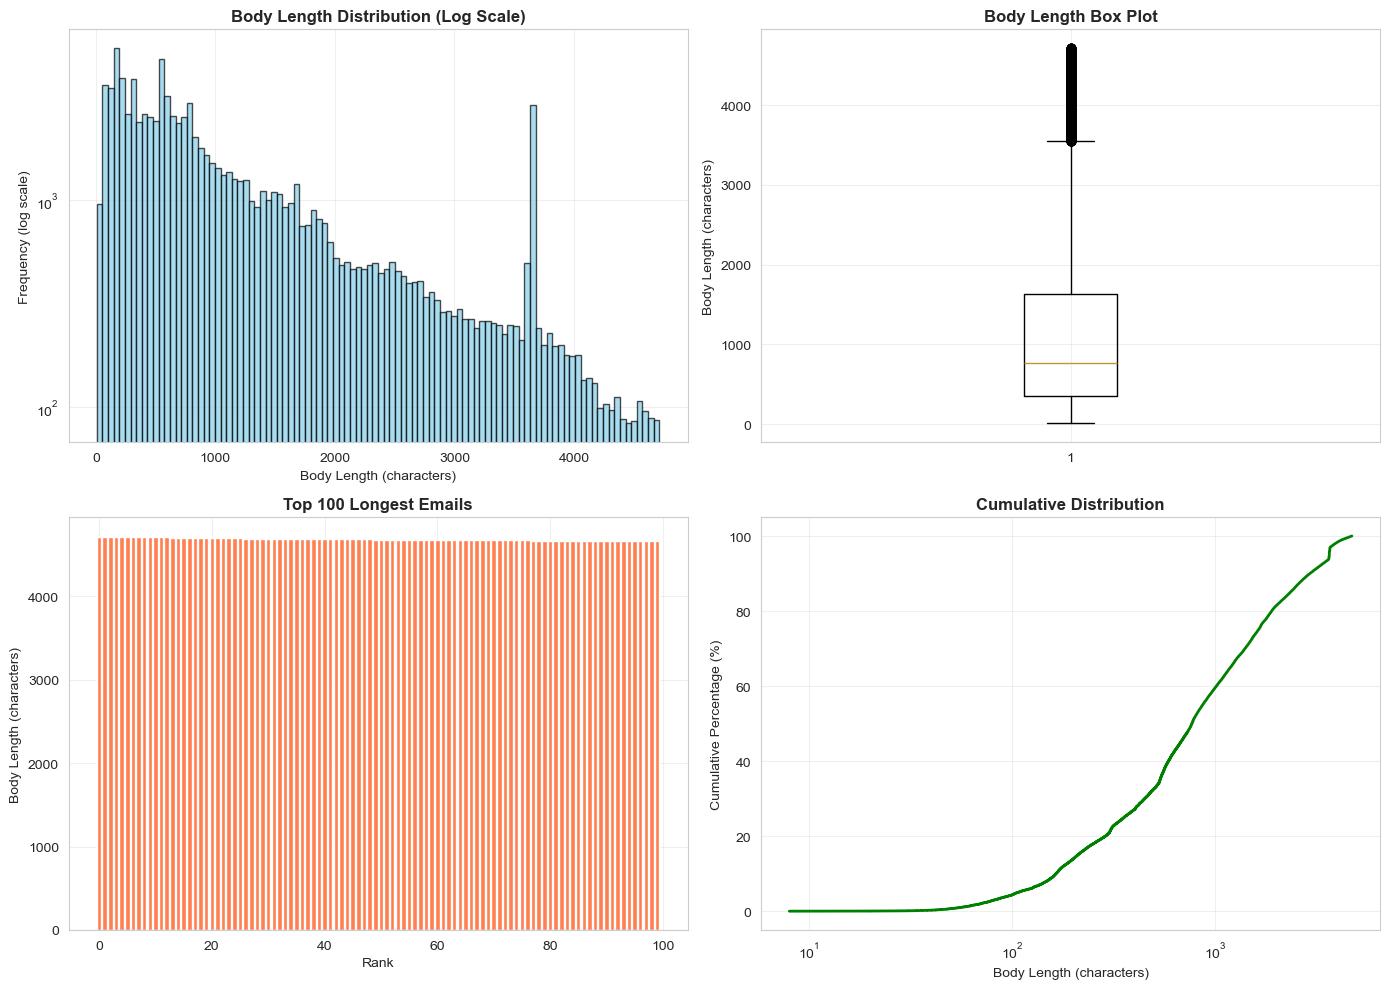

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram with log scale
axes[0, 0].hist(email_df['body_length'], bins=100, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Body Length Distribution (Log Scale)', fontweight='bold')
axes[0, 0].set_xlabel('Body Length (characters)')
axes[0, 0].set_ylabel('Frequency (log scale)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot
axes[0, 1].boxplot(email_df['body_length'], vert=True)
axes[0, 1].set_title('Body Length Box Plot', fontweight='bold')
axes[0, 1].set_ylabel('Body Length (characters)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Top 100 longest emails
top_100 = email_df.nlargest(100, 'body_length')['body_length']
axes[1, 0].bar(range(len(top_100)), top_100.values, color='coral')
axes[1, 0].set_title('Top 100 Longest Emails', fontweight='bold')
axes[1, 0].set_xlabel('Rank')
axes[1, 0].set_ylabel('Body Length (characters)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Cumulative distribution
sorted_lengths = np.sort(email_df['body_length'])
cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100
axes[1, 1].plot(sorted_lengths, cumulative, linewidth=2, color='green')
axes[1, 1].set_title('Cumulative Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Body Length (characters)')
axes[1, 1].set_ylabel('Cumulative Percentage (%)')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Drop temporary column
email_df = email_df.drop('body_length', axis=1)


4. Text-specific cleaning - Remove empty bodies, weird encoding, etc.

##  1. EMPTY OR MINIMAL CONTENT

In [22]:

print(f"\nAnalyzing {len(email_df):,} emails for text quality issues...")

print("\n" + "="*70)
print("1. EMPTY OR MINIMAL CONTENT ANALYSIS")
print("="*70)

# Check body lengths
email_df['body_length'] = email_df['body'].str.len()
email_df['body_word_count'] = email_df['body'].str.split().str.len()

print("\nBody Length Statistics:")
print(email_df['body_length'].describe())

print("\nWord Count Statistics:")
print(email_df['body_word_count'].describe())

# Very short bodies
very_short = email_df[email_df['body_length'] < 50]
print(f"\nVery short bodies (<50 chars): {len(very_short):,} ({len(very_short)/len(email_df)*100:.2f}%)")
if len(very_short) > 0:
    print("\nSample very short bodies:")
    for idx, row in very_short.head(10).iterrows():
        print(f"  Subject: {row['subject'][:50]}... | Body: '{row['body'][:100]}' | Label: {row['label']}")

# Very few words
few_words = email_df[email_df['body_word_count'] < 5]
print(f"\nVery few words (<5 words): {len(few_words):,} ({len(few_words)/len(email_df)*100:.2f}%)")

# Empty or whitespace only
empty_or_whitespace = email_df[email_df['body'].str.strip().str.len() == 0]
print(f"Empty or whitespace-only bodies: {len(empty_or_whitespace):,}")


Analyzing 100,038 emails for text quality issues...

1. EMPTY OR MINIMAL CONTENT ANALYSIS

Body Length Statistics:
count   100038.00
mean      1159.79
std       1070.19
min          8.00
25%        357.00
50%        768.00
75%       1634.00
max       4714.00
Name: body_length, dtype: float64

Word Count Statistics:
count   100038.00
mean       170.94
std        156.43
min          1.00
25%         54.00
50%        118.00
75%        248.00
max       1278.00
Name: body_word_count, dtype: float64

Very short bodies (<50 chars): 648 (0.65%)

Sample very short bodies:
  Subject: It will rise faster and stay up longer.... | Body: 'Your one and only online Chemist. Click here!' | Label: 1
  Subject: do you have 10 inches? Maybe You want enlarge him... | Body: 'Do you want Enlarge your Penis?' | Label: 1
  Subject: Goodiest giovanne solution... | Body: 'approved, medication fast delivery check out here' | Label: 1
  Subject: Good jeramey proposition... | Body: 'purchase, pills safe and effect

## 2. HTML/XML CONTENT

In [23]:
# Overall HTML tag detection
has_html_tags = email_df['body'].str.contains('<[^>]+>', regex=True, na=False)
html_count = has_html_tags.sum()
print(f"\nEmails with ANY HTML tags: {html_count:,} ({html_count/len(email_df)*100:.2f}%)")

# ============================================================================
# 1. DETECT ALL UNIQUE HTML TAGS DYNAMICALLY
# ============================================================================
print("\n" + "="*70)
print("1. ALL UNIQUE HTML TAGS FOUND")
print("="*70)

# Extract all HTML tags from all emails
all_tags = []
for body in email_df[has_html_tags]['body']:
    tags = re.findall(r'<(/?)([a-zA-Z][a-zA-Z0-9]*)', body)
    all_tags.extend([tag[1].lower() for tag in tags])

# Count tag frequency
tag_counter = Counter(all_tags)
print(f"\nTotal unique HTML tags found: {len(tag_counter)}")
print("\nTop 30 most common HTML tags:")
for tag, count in tag_counter.most_common(30):
    pct = count / html_count * 100
    print(f"  <{tag}>: {count:,} occurrences ({pct:.2f}% of HTML emails)")

# ============================================================================
# 2. STRUCTURAL HTML TAGS
# ============================================================================
print("\n" + "="*70)
print("2. STRUCTURAL HTML TAGS")
print("="*70)

structural_tags = {
    'html': email_df['body'].str.contains(r'<html[^>]*>', case=False, regex=True, na=False).sum(),
    'head': email_df['body'].str.contains(r'<head[^>]*>', case=False, regex=True, na=False).sum(),
    'body': email_df['body'].str.contains(r'<body[^>]*>', case=False, regex=True, na=False).sum(),
    'meta': email_df['body'].str.contains(r'<meta[^>]*>', case=False, regex=True, na=False).sum(),
    'title': email_df['body'].str.contains(r'<title[^>]*>', case=False, regex=True, na=False).sum(),
    'style': email_df['body'].str.contains(r'<style[^>]*>', case=False, regex=True, na=False).sum(),
    'script': email_df['body'].str.contains(r'<script[^>]*>', case=False, regex=True, na=False).sum(),
}

print("\nStructural HTML tag frequency:")
for tag, count in structural_tags.items():
    print(f"  <{tag}>: {count:,} ({count/len(email_df)*100:.2f}%)")

# ============================================================================
# 3. LAYOUT/FORMATTING HTML TAGS
# ============================================================================
print("\n" + "="*70)
print("3. LAYOUT & FORMATTING HTML TAGS")
print("="*70)

layout_tags = {
    'div': email_df['body'].str.contains(r'<div[^>]*>', case=False, regex=True, na=False).sum(),
    'span': email_df['body'].str.contains(r'<span[^>]*>', case=False, regex=True, na=False).sum(),
    'p': email_df['body'].str.contains(r'<p[^>]*>', case=False, regex=True, na=False).sum(),
    'br': email_df['body'].str.contains(r'<br[^>]*>', case=False, regex=True, na=False).sum(),
    'table': email_df['body'].str.contains(r'<table[^>]*>', case=False, regex=True, na=False).sum(),
    'tr': email_df['body'].str.contains(r'<tr[^>]*>', case=False, regex=True, na=False).sum(),
    'td': email_df['body'].str.contains(r'<td[^>]*>', case=False, regex=True, na=False).sum(),
    'th': email_df['body'].str.contains(r'<th[^>]*>', case=False, regex=True, na=False).sum(),
}

print("\nLayout/Formatting tag frequency:")
for tag, count in layout_tags.items():
    print(f"  <{tag}>: {count:,} ({count/len(email_df)*100:.2f}%)")

# ============================================================================
# 4. TEXT FORMATTING HTML TAGS
# ============================================================================
print("\n" + "="*70)
print("4. TEXT FORMATTING HTML TAGS")
print("="*70)

text_tags = {
    'b': email_df['body'].str.contains(r'<b[^>]*>', case=False, regex=True, na=False).sum(),
    'strong': email_df['body'].str.contains(r'<strong[^>]*>', case=False, regex=True, na=False).sum(),
    'i': email_df['body'].str.contains(r'<i[^>]*>', case=False, regex=True, na=False).sum(),
    'em': email_df['body'].str.contains(r'<em[^>]*>', case=False, regex=True, na=False).sum(),
    'u': email_df['body'].str.contains(r'<u[^>]*>', case=False, regex=True, na=False).sum(),
    'font': email_df['body'].str.contains(r'<font[^>]*>', case=False, regex=True, na=False).sum(),
    'h1-h6': email_df['body'].str.contains(r'<h[1-6][^>]*>', case=False, regex=True, na=False).sum(),
}

print("\nText formatting tag frequency:")
for tag, count in text_tags.items():
    print(f"  <{tag}>: {count:,} ({count/len(email_df)*100:.2f}%)")

# ============================================================================
# 5. INTERACTIVE HTML TAGS (Links, Images, Forms)
# ============================================================================
print("\n" + "="*70)
print("5. INTERACTIVE HTML TAGS")
print("="*70)

interactive_tags = {
    'a (links)': email_df['body'].str.contains(r'<a[^>]*>', case=False, regex=True, na=False).sum(),
    'img': email_df['body'].str.contains(r'<img[^>]*>', case=False, regex=True, na=False).sum(),
    'form': email_df['body'].str.contains(r'<form[^>]*>', case=False, regex=True, na=False).sum(),
    'input': email_df['body'].str.contains(r'<input[^>]*>', case=False, regex=True, na=False).sum(),
    'button': email_df['body'].str.contains(r'<button[^>]*>', case=False, regex=True, na=False).sum(),
    'iframe': email_df['body'].str.contains(r'<iframe[^>]*>', case=False, regex=True, na=False).sum(),
}

print("\nInteractive tag frequency:")
for tag, count in interactive_tags.items():
    print(f"  <{tag}>: {count:,} ({count/len(email_df)*100:.2f}%)")

# ============================================================================
# 6. HTML COMMENT DETECTION
# ============================================================================
print("\n" + "="*70)
print("6. HTML COMMENTS")
print("="*70)

has_comments = email_df['body'].str.contains(r'<!--.*?-->', regex=True, na=False).sum()
print(f"\nEmails with HTML comments: {has_comments:,} ({has_comments/len(email_df)*100:.2f}%)")

# ============================================================================
# 7. MALFORMED/ESCAPED HTML
# ============================================================================
print("\n" + "="*70)
print("7. MALFORMED OR ESCAPED HTML")
print("="*70)

malformed_patterns = {
    'Unclosed tags': email_df['body'].str.count(r'<[a-zA-Z][^>]*$').sum(),
    'Escaped < as &lt;': email_df['body'].str.contains(r'&lt;', regex=False, na=False).sum(),
    'Escaped > as &gt;': email_df['body'].str.contains(r'&gt;', regex=False, na=False).sum(),
    'HTML in plain text (=3C)': email_df['body'].str.contains(r'=3C[a-zA-Z]', regex=True, na=False).sum(),
}

print("\nMalformed/Escaped HTML patterns:")
for pattern, count in malformed_patterns.items():
    print(f"  {pattern}: {count:,} ({count/len(email_df)*100:.2f}%)")

# ============================================================================
# 8. HTML DENSITY ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("8. HTML DENSITY ANALYSIS")
print("="*70)

# Calculate HTML tag density for emails with HTML
email_df['html_tag_count'] = email_df['body'].str.count(r'<[^>]+>')
email_df['body_length_temp'] = email_df['body'].str.len()
email_df['html_density'] = email_df['html_tag_count'] / email_df['body_length_temp']

html_emails = email_df[has_html_tags]
print(f"\nHTML tag count statistics (for emails with HTML):")
print(html_emails['html_tag_count'].describe())

print(f"\nHTML density statistics (tags per character):")
print(html_emails['html_density'].describe())

# Heavy HTML emails
heavy_html = email_df[email_df['html_tag_count'] > 50]
print(f"\nEmails with >50 HTML tags: {len(heavy_html):,} ({len(heavy_html)/len(email_df)*100:.2f}%)")

# Very high HTML density (mostly HTML, little text)
high_density = email_df[email_df['html_density'] > 0.1]
print(f"Emails with >10% HTML density: {len(high_density):,} ({len(high_density)/len(email_df)*100:.2f}%)")

# ============================================================================
# 9. SAMPLE HTML EMAILS BY CATEGORY
# ============================================================================
print("\n" + "="*70)
print("9. SAMPLE HTML EMAILS")
print("="*70)

# Full HTML documents
full_html = email_df['body'].str.contains(r'<html[^>]*>.*<head[^>]*>.*<body[^>]*>', case=False, regex=True, na=False)
print(f"\nFull HTML documents (<html><head><body>): {full_html.sum():,}")
if full_html.sum() > 0:
    print("\nSample full HTML documents:")
    for idx, row in email_df[full_html].head(2).iterrows():
        print(f"\n  Subject: {row['subject'][:60]}...")
        print(f"  Label: {row['label']} | HTML tags: {row['html_tag_count']}")
        print(f"  Body preview: {row['body'][:300]}...")

# Partial HTML (fragments)
partial_html = has_html_tags & ~full_html
print(f"\nPartial HTML (fragments): {partial_html.sum():,}")
if partial_html.sum() > 0:
    print("\nSample partial HTML:")
    for idx, row in email_df[partial_html].head(2).iterrows():
        print(f"\n  Subject: {row['subject'][:60]}...")
        print(f"  Label: {row['label']} | HTML tags: {row['html_tag_count']}")
        print(f"  Body preview: {row['body'][:300]}...")

# Drop temporary columns
email_df = email_df.drop(['html_tag_count', 'body_length_temp', 'html_density'], axis=1)



Emails with ANY HTML tags: 7,203 (7.20%)

1. ALL UNIQUE HTML TAGS FOUND

Total unique HTML tags found: 184

Top 30 most common HTML tags:
  <div>: 31 occurrences (0.43% of HTML emails)
  <http>: 25 occurrences (0.35% of HTML emails)
  <rpm>: 23 occurrences (0.32% of HTML emails)
  <font>: 20 occurrences (0.28% of HTML emails)
  <mailto>: 16 occurrences (0.22% of HTML emails)
  <a>: 12 occurrences (0.17% of HTML emails)
  <embedded>: 12 occurrences (0.17% of HTML emails)
  <br>: 10 occurrences (0.14% of HTML emails)
  <smaller>: 8 occurrences (0.11% of HTML emails)
  <heidiho>: 6 occurrences (0.08% of HTML emails)
  <u>: 6 occurrences (0.08% of HTML emails)
  <term>: 6 occurrences (0.08% of HTML emails)
  <closing>: 5 occurrences (0.07% of HTML emails)
  <expr>: 5 occurrences (0.07% of HTML emails)
  <p>: 4 occurrences (0.06% of HTML emails)
  <schwartz>: 4 occurrences (0.06% of HTML emails)
  <tr>: 3 occurrences (0.04% of HTML emails)
  <majority>: 3 occurrences (0.04% of HTML emails)

## 3. ENCODING ISSUES

In [24]:
# Non-ASCII characters
has_non_ascii = email_df['body'].str.contains(r'[^\x00-\x7F]', regex=True, na=False)
non_ascii_count = has_non_ascii.sum()
print(f"\nEmails with non-ASCII characters: {non_ascii_count:,} ({non_ascii_count/len(email_df)*100:.2f}%)")

# Common encoding patterns
encoding_patterns = {
    'HTML entities (&...;)': email_df['body'].str.contains(r'&[a-z]+;', case=False, regex=True, na=False).sum(),
    'Hex encoding (\\x..)': email_df['body'].str.contains(r'\\x[0-9a-f]{2}', case=False, regex=True, na=False).sum(),
    'Unicode escapes (\\u..)': email_df['body'].str.contains(r'\\u[0-9a-f]{4}', case=False, regex=True, na=False).sum(),
    'Quoted-printable (=XX)': email_df['body'].str.contains(r'=[0-9A-F]{2}', regex=True, na=False).sum(),
    'Base64-like': email_df['body'].str.contains(r'[A-Za-z0-9+/]{50,}={0,2}', regex=True, na=False).sum(),
}

print("\nEncoding pattern frequency:")
for pattern, count in encoding_patterns.items():
    print(f"  {pattern}: {count:,} ({count/len(email_df)*100:.2f}%)")

# Sample non-ASCII content
if non_ascii_count > 0:
    print("\nSample non-ASCII content (first 3):")
    for idx, row in email_df[has_non_ascii].head(3).iterrows():
        print(f"\n  Subject: {row['subject'][:60]}...")
        print(f"  Body preview: {row['body'][:200]}...")



Emails with non-ASCII characters: 13,183 (13.18%)

Encoding pattern frequency:
  HTML entities (&...;): 45 (0.04%)
  Hex encoding (\x..): 100 (0.10%)
  Unicode escapes (\u..): 36 (0.04%)
  Quoted-printable (=XX): 6,368 (6.37%)
  Base64-like: 3,106 (3.10%)

Sample non-ASCII content (first 3):

  Subject: RE: Trial IRC Certificate Application...
  Body preview: Plelim, Just to remind you that if a certificate is needed in a hurry it can be expedited. This process is double the cost of a normal application. The normal cost for a Trial Certificate is LOA(m)x €...

  Subject: ScienceNOW Daily Email Alert...
  Body preview: ScienceNOW Week in Review >All Free Articles | >Top 10 Last Month | >ScienceShots | >Daily News Archive | >About ScienceNOW All these ScienceNOW stories, and more, are available at: www.sciencenow.org...

  Subject: WinnipegFreePress.com Breaking News...
  Body preview: Aug. 5, 2008 News Business | Entertainment | Sports | Lifestyle | Opinions Breaking News Li asks court

## 4. WHITESPACE ISSUES

In [25]:
# Excessive whitespace
excessive_spaces = email_df['body'].str.contains(r' {5,}', regex=True, na=False).sum()
excessive_newlines = email_df['body'].str.contains(r'\n{5,}', regex=True, na=False).sum()
excessive_tabs = email_df['body'].str.contains(r'\t{3,}', regex=True, na=False).sum()

print(f"\nExcessive whitespace issues:")
print(f"  5+ consecutive spaces: {excessive_spaces:,} ({excessive_spaces/len(email_df)*100:.2f}%)")
print(f"  5+ consecutive newlines: {excessive_newlines:,} ({excessive_newlines/len(email_df)*100:.2f}%)")
print(f"  3+ consecutive tabs: {excessive_tabs:,} ({excessive_tabs/len(email_df)*100:.2f}%)")

# Leading/trailing whitespace
leading_whitespace = email_df['body'].str.match(r'^\s+').sum()
trailing_whitespace = email_df['body'].str.match(r'.*\s+$').sum()
print(f"  Leading whitespace: {leading_whitespace:,} ({leading_whitespace/len(email_df)*100:.2f}%)")
print(f"  Trailing whitespace: {trailing_whitespace:,} ({trailing_whitespace/len(email_df)*100:.2f}%)")



Excessive whitespace issues:
  5+ consecutive spaces: 0 (0.00%)
  5+ consecutive newlines: 0 (0.00%)
  3+ consecutive tabs: 0 (0.00%)
  Leading whitespace: 0 (0.00%)
  Trailing whitespace: 0 (0.00%)


## 5. SPECIAL CHARACTERS & SYMBOLS

In [26]:
special_chars = {
    'Null bytes (\\x00)': email_df['body'].str.contains('\x00', regex=False, na=False).sum(),
    'Control characters': email_df['body'].str.contains(r'[\x00-\x08\x0B\x0C\x0E-\x1F]', regex=True, na=False).sum(),
    'Replacement char (�)': email_df['body'].str.contains('�', regex=False, na=False).sum(),
    'Currency symbols': email_df['body'].str.contains(r'[$€£¥₹]', regex=True, na=False).sum(),
    'Emoji/emoticons': email_df['body'].str.contains(r'[😀-🙏🌀-🗿🚀-🛿]|:\)|:\(|:D|:P', regex=True, na=False).sum(),
}

print("\nSpecial character frequency:")
for char_type, count in special_chars.items():
    print(f"  {char_type}: {count:,} ({count/len(email_df)*100:.2f}%)")



Special character frequency:
  Null bytes (\x00): 0 (0.00%)
  Control characters: 107 (0.11%)
  Replacement char (�): 0 (0.00%)
  Currency symbols: 18,631 (18.62%)
  Emoji/emoticons: 2,605 (2.60%)


## 6. MIME/EMAIL HEADERS IN BODY

In [27]:
header_patterns = {
    'Content-Type:': email_df['body'].str.contains('Content-Type:', case=False, regex=False, na=False).sum(),
    'MIME-Version:': email_df['body'].str.contains('MIME-Version:', case=False, regex=False, na=False).sum(),
    'Content-Transfer-Encoding:': email_df['body'].str.contains('Content-Transfer-Encoding:', case=False, regex=False, na=False).sum(),
    'multipart/': email_df['body'].str.contains('multipart/', case=False, regex=False, na=False).sum(),
    'boundary=': email_df['body'].str.contains('boundary=', case=False, regex=False, na=False).sum(),
}

print("\nMIME header frequency in body:")
for header, count in header_patterns.items():
    print(f"  {header}: {count:,} ({count/len(email_df)*100:.2f}%)")

# Sample MIME content
mime_in_body = email_df['body'].str.contains('Content-Type:|MIME-Version:', case=False, regex=True, na=False)
if mime_in_body.sum() > 0:
    print(f"\nEmails with MIME headers in body: {mime_in_body.sum():,}")
    print("\nSample (first 2):")
    for idx, row in email_df[mime_in_body].head(2).iterrows():
        print(f"\n  Subject: {row['subject'][:60]}...")
        print(f"  Body preview: {row['body'][:300]}...")




MIME header frequency in body:
  Content-Type:: 922 (0.92%)
  MIME-Version:: 256 (0.26%)
  Content-Transfer-Encoding:: 534 (0.53%)
  multipart/: 204 (0.20%)
  boundary=: 90 (0.09%)

Emails with MIME headers in body: 935

Sample (first 2):

  Subject: TuxOnIce-users Digest, Vol 36, Issue 10...
  Body preview: Send TuxOnIce-users mailing list submissions to enpsfhxz-stvnz@lists.tuxonice.net To subscribe or unsubscribe via the World Wide Web, visit http://lists.tuxonice.net/mailman/listinfo/tuxonice-users or, via email, send a message with subject or body 'help' to ysxshwee-tyrxx-liyysxs@lists.tuxonice.net...

  Subject: Re: Getting ? in spam scores....
  Body preview: Thank you. I have check my DNS and it appears to resolve the link correctly. It is just annoying, I think less than 1% of all messages, are getting this and I'm checking if there is something I can do to solve this. Here is a sample message that is causing this: >From ohtecu-vmup@Freeburghcabins.com...


## 7. SUBJECT LINE QUALITY

In [28]:
# Subject length
email_df['subject_length'] = email_df['subject'].fillna('').str.len()
print("\nSubject Length Statistics:")
print(email_df['subject_length'].describe())

# Empty/missing subjects
empty_subjects = email_df['subject'].isna() | (email_df['subject'].str.strip() == '')
print(f"\nEmpty/missing subjects: {empty_subjects.sum():,} ({empty_subjects.sum()/len(email_df)*100:.2f}%)")

# All caps subjects
all_caps = email_df['subject'].fillna('').str.isupper() & (email_df['subject'].str.len() > 0)
print(f"All-caps subjects: {all_caps.sum():,} ({all_caps.sum()/len(email_df)*100:.2f}%)")

# Subjects with excessive punctuation
excessive_punct = email_df['subject'].fillna('').str.count(r'[!?]{3,}').sum()
print(f"Subjects with 3+ consecutive !/?: {excessive_punct:,}")

# Sample all-caps subjects
if all_caps.sum() > 0:
    print("\nSample all-caps subjects:")
    for subject in email_df[all_caps]['subject'].head(5):
        print(f"  - {subject[:80]}")



Subject Length Statistics:
count   100038.00
mean        37.94
std         25.73
min          0.00
25%         22.00
50%         33.00
75%         49.00
max       2657.00
Name: subject_length, dtype: float64

Empty/missing subjects: 601 (0.60%)
All-caps subjects: 2,725 (2.72%)
Subjects with 3+ consecutive !/?: 442

Sample all-caps subjects:
  - ALL MAJOR DESIGNER REPLICA W ATCHES!
  - FW: КАЧЕСТВЕННЫЕ ПЛАСТИКОВЫЕ ОКНА
  - [UAI] IEA/AIE-2005 - CALL FOR PAPERS
  - [UAI] CFP: SAT 2005
  - FINANCE/ACCOUNTING VACANCY


## 8. URL PATTERNS

In [29]:
# URL detection
has_urls = email_df['body'].str.contains(r'https?://|www\.', case=False, regex=True, na=False)
url_count = has_urls.sum()
print(f"\nEmails with URLs: {url_count:,} ({url_count/len(email_df)*100:.2f}%)")

# Count URLs per email
email_df['url_count_body'] = email_df['body'].str.count(r'https?://|www\.', flags=re.IGNORECASE)
print(f"\nURL count statistics:")
print(email_df['url_count_body'].describe())

# Emails with many URLs
many_urls = email_df[email_df['url_count_body'] > 10]
print(f"\nEmails with >10 URLs: {len(many_urls):,} ({len(many_urls)/len(email_df)*100:.2f}%)")
if len(many_urls) > 0:
    print("\nSample emails with many URLs:")
    for idx, row in many_urls.head(3).iterrows():
        print(f"  Subject: {row['subject'][:60]}... | URL count: {row['url_count_body']} | Label: {row['label']}")


Emails with URLs: 60,012 (59.99%)

URL count statistics:
count   100038.00
mean         2.92
std          8.18
min          0.00
25%          0.00
50%          1.00
75%          2.00
max        128.00
Name: url_count_body, dtype: float64

Emails with >10 URLs: 3,952 (3.95%)

Sample emails with many URLs:
  Subject: CNN.com Daily Top 10... | URL count: 47 | Label: 1
  Subject: CNN.com Daily Top 10... | URL count: 47 | Label: 1
  Subject: CNN.com Daily Top 10... | URL count: 47 | Label: 1


## 9. SUSPICIOUS PATTERNS

In [30]:
suspicious_patterns = {
    'Click here': email_df['body'].str.contains(r'click\s+here', case=False, regex=True, na=False).sum(),
    'Verify account': email_df['body'].str.contains(r'verify\s+(your\s+)?account', case=False, regex=True, na=False).sum(),
    'Urgent action': email_df['body'].str.contains(r'urgent|immediately|act\s+now', case=False, regex=True, na=False).sum(),
    'Dear customer': email_df['body'].str.contains(r'dear\s+(customer|user|member)', case=False, regex=True, na=False).sum(),
    'Congratulations': email_df['body'].str.contains(r'congratulations|you\'?ve?\s+won', case=False, regex=True, na=False).sum(),
    'Free money/gift': email_df['body'].str.contains(r'free\s+(money|gift|prize|cash)', case=False, regex=True, na=False).sum(),
}

print("\nSuspicious pattern frequency:")
for pattern, count in suspicious_patterns.items():
    print(f"  {pattern}: {count:,} ({count/len(email_df)*100:.2f}%)")


Suspicious pattern frequency:
  Click here: 8,708 (8.70%)
  Verify account: 97 (0.10%)
  Urgent action: 3,791 (3.79%)
  Dear customer: 1,325 (1.32%)
  Congratulations: 279 (0.28%)
  Free money/gift: 339 (0.34%)


## 10. LANGUAGE DETECTION

In [31]:
# Mostly ASCII
mostly_ascii = email_df['body'].str.encode('ascii', errors='ignore').str.decode('ascii').str.len() / email_df['body_length'] > 0.95
print(f"\nMostly ASCII (>95%): {mostly_ascii.sum():,} ({mostly_ascii.sum()/len(email_df)*100:.2f}%)")

# Non-English characters
has_cyrillic = email_df['body'].str.contains(r'[А-Яа-я]', regex=True, na=False).sum()
has_chinese = email_df['body'].str.contains(r'[\u4e00-\u9fff]', regex=True, na=False).sum()
has_arabic = email_df['body'].str.contains(r'[\u0600-\u06ff]', regex=True, na=False).sum()
has_japanese = email_df['body'].str.contains(r'[\u3040-\u309f\u30a0-\u30ff]', regex=True, na=False).sum()

print(f"\nNon-English scripts:")
print(f"  Cyrillic: {has_cyrillic:,} ({has_cyrillic/len(email_df)*100:.2f}%)")
print(f"  Chinese: {has_chinese:,} ({has_chinese/len(email_df)*100:.2f}%)")
print(f"  Arabic: {has_arabic:,} ({has_arabic/len(email_df)*100:.2f}%)")
print(f"  Japanese: {has_japanese:,} ({has_japanese/len(email_df)*100:.2f}%)")

# Drop temporary columns
email_df = email_df.drop(['body_length', 'body_word_count', 'subject_length', 'url_count_body'], axis=1)



Mostly ASCII (>95%): 99,905 (99.87%)

Non-English scripts:
  Cyrillic: 95 (0.09%)
  Chinese: 238 (0.24%)
  Arabic: 3 (0.00%)
  Japanese: 92 (0.09%)


#### Minor issues:

* 648 very short bodies (0.65%) - KEEP: These are valid phishing patterns (short spam messages)
* 601 empty subjects (0.60%) - KEEP: Can handle in missing data step
* 6,368 quoted-printable encoding (6.37%) - KEEP: Valid email encoding, useful for phishing detection
* 13,183 non-ASCII (13.18%) - KEEP: Legitimate international emails

### Hence we will only clean and remove the html in the bodies so that we will only remain with text only.

### HTML CLEANING: REMOVE ALL HTML FROM EMAIL BODIES

In [32]:
# Store initial state
initial_count = len(email_df)
has_html_before = email_df['body'].str.contains('<[^>]+>', regex=True, na=False).sum()

print(f"\nStarting with: {initial_count:,} emails")
print(f"Emails with HTML tags: {has_html_before:,} ({has_html_before/initial_count*100:.2f}%)")


Starting with: 100,038 emails
Emails with HTML tags: 7,203 (7.20%)


In [33]:
def clean_html_from_text(text):
    """
    3-step HTML cleaning:
    1. Pre-process: Normalize malformed HTML
    2. Parse: BeautifulSoup extraction
    3. Post-process: Remove remaining HTML artifacts
    """
    if pd.isna(text):
        return text

    # Quick check - does this text actually contain HTML?
    html_indicators = ['<br', '<div', '<span', '<a href', '<img', '<table',
                       '<font', '<b>', '<i>', '<strong>', '<em>', '</', '< ']

    has_html = any(indicator in text.lower() for indicator in html_indicators)

    if not has_html:
        return text

    # STEP 1: PRE-PROCESSING - NORMALIZE MALFORMED HTML
    # 1a. Remove spaces inside tags: < br> → <br>, < div > → <div>
    text = re.sub(r'<\s+', '<', text)  # Remove leading spaces
    text = re.sub(r'\s+>', '>', text)  # Remove trailing spaces

    # 1b. Fix incomplete href attributes (missing quotes)
    # href=http:// → href="http://"
    text = re.sub(r'href=([^"\s>]+)', r'href="\1"', text, flags=re.IGNORECASE)
    text = re.sub(r'src=([^"\s>]+)', r'src="\1"', text, flags=re.IGNORECASE)

    # 1c. Close incomplete tags at end of string
    # <a href="...  → <a href="...">
    text = re.sub(r'<([a-zA-Z][a-zA-Z0-9]*)\s+[^>]*$', r'<\1>', text)

    # 1d. Fix common malformed patterns
    text = text.replace('< =', '<=')  # Math operator, not tag
    text = text.replace('> =', '>=')  # Math operator, not tag

    # STEP 2: EXTRACT URLs BEFORE BEAUTIFULSOUP
    # Extract URLs from <a href> tags before parsing
    href_pattern = r'<a[^>]+href=["\']([^"\']+)["\'][^>]*>(.*?)</a>'

    def replace_link(match):
        url = match.group(1)
        link_text = match.group(2)
        if link_text.strip():
            return f"{link_text} {url}"
        else:
            return url

    text = re.sub(href_pattern, replace_link, text, flags=re.IGNORECASE | re.DOTALL)

    # Extract URLs from img and iframe src
    img_pattern = r'<img[^>]+src=["\']([^"\']+)["\'][^>]*>'
    text = re.sub(img_pattern, r' \1 ', text, flags=re.IGNORECASE)

    iframe_pattern = r'<iframe[^>]+src=["\']([^"\']+)["\'][^>]*>'
    text = re.sub(iframe_pattern, r' \1 ', text, flags=re.IGNORECASE)

    # STEP 3: BEAUTIFULSOUP PARSING
    try:
        soup = BeautifulSoup(text, 'html.parser')

        # Remove script and style elements
        for script in soup(['script', 'style']):
            script.decompose()

        # Extract text
        text = soup.get_text(separator=' ')

    except Exception as e:
        # If BeautifulSoup fails, continue to post-processing
        pass

    # STEP 4: POST-PROCESSING - REMOVE REMAINING HTML ARTIFACTS
    # 4a. Remove any remaining known HTML tags (case-insensitive)
    # This catches tags that BeautifulSoup missed
    html_tags = (
        'html|head|body|title|meta|link|style|script|'
        'div|span|p|br|hr|a|img|picture|source|'
        'table|thead|tbody|tfoot|tr|td|th|caption|colgroup|col|'
        'ul|ol|li|dl|dt|dd|'
        'form|input|button|select|option|textarea|label|fieldset|legend|'
        'h1|h2|h3|h4|h5|h6|'
        'strong|b|i|em|u|s|strike|del|ins|sub|sup|small|mark|'
        'iframe|embed|object|param|video|audio|canvas|svg|'
        'font|center|marquee|blink'
    )

    # Remove opening/closing/self-closing HTML tags
    # Pattern: <tag>, <tag attr="value">, </tag>, <tag/>
    html_tag_pattern = f'</?(?:{html_tags})(?:\\s+[^>]*)?\\/?>|<\\/(?:{html_tags})>'
    text = re.sub(html_tag_pattern, ' ', text, flags=re.IGNORECASE)

    # 4b. Remove tags with attributes (anything with spaces inside)
    # <tag attr="value"> but NOT <email@domain.com> or <-
    text = re.sub(r'<([a-zA-Z][a-zA-Z0-9]*)\s+[^>]*>', ' ', text)

    # 4c. Remove self-closing tags: <tag/>
    text = re.sub(r'<([a-zA-Z][a-zA-Z0-9]*)/>', ' ', text)

    # 4d. Remove incomplete tags at end of string
    text = re.sub(r'<[^>]*$', '', text)

    # 4e. Remove HTML comments (any remaining)
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)

    # STEP 5: DECODE HTML ENTITIES
    html_entities = {
        '&nbsp;': ' ',
        '&amp;': '&',
        '&lt;': '<',
        '&gt;': '>',
        '&quot;': '"',
        '&apos;': "'",
        '&#39;': "'",
        '&ndash;': '-',
        '&mdash;': '—',
        '&hellip;': '...',
        '&bull;': '•',
        '&copy;': '©',
        '&reg;': '®',
        '&trade;': '™',
    }

    for entity, char in html_entities.items():
        text = text.replace(entity, char)

    # Decode numeric HTML entities
    text = re.sub(r'&#(\d+);', lambda m: chr(int(m.group(1))) if int(m.group(1)) < 1114112 else m.group(0), text)
    text = re.sub(r'&#x([0-9a-fA-F]+);', lambda m: chr(int(m.group(1), 16)) if int(m.group(1), 16) < 1114112 else m.group(0), text)

    # Remove any remaining HTML entity references
    text = re.sub(r'&[a-zA-Z]{2,8};', ' ', text)
    text = re.sub(r'&#[0-9]{1,6};', ' ', text)

    # STEP 6: CLEAN UP QUOTED-PRINTABLE AND WHITESPACE
    # Remove quoted-printable encoding
    text = re.sub(r'=3C[^=]*?=3E', '', text)
    text = re.sub(r'=3C[^=]*$', '', text)

    # Clean up whitespace
    text = re.sub(r' {2,}', ' ', text)  # Multiple spaces → single space
    text = re.sub(r'\n{3,}', '\n\n', text)  # Multiple newlines → max 2
    text = text.replace('\t', ' ')  # Tabs → spaces
    text = text.strip()  # Remove leading/trailing whitespace

    return text

In [34]:

# APPLY HTML CLEANING
# Apply cleaning function to body column
email_df['body'] = email_df['body'].apply(clean_html_from_text)

# Also clean subject line (in case it has HTML)
email_df['subject'] = email_df['subject'].apply(clean_html_from_text)

print("✓ HTML cleaning applied to body and subject")


✓ HTML cleaning applied to body and subject


#### VERIFICATION: CHECKING FOR REMAINING HTML

In [35]:
# INVESTIGATING REMAINING 'HTML TAGS' - SHOW ACTUAL CONTENT
# Find emails with remaining angle brackets
has_brackets = email_df['body'].str.contains('<[^>]+>', regex=True, na=False)
emails_with_brackets = email_df[has_brackets]

print(f"\nEmails with angle brackets: {len(emails_with_brackets):,} ({len(emails_with_brackets)/len(email_df)*100:.2f}%)")


Emails with angle brackets: 3,810 (3.81%)


In [36]:
# SHOW RAW EXAMPLES OF ANGLE BRACKET CONTENT
print("\nShowing 20 random emails with their 'HTML tags' in context:\n")

sample_size = min(20, len(emails_with_brackets))
sample_emails = emails_with_brackets.sample(sample_size, random_state=42)

for i, (idx, row) in enumerate(sample_emails.iterrows(), 1):
    # Extract all angle bracket content from this email
    brackets = re.findall(r'<[^>]+>', row['body'])

    print(f"{'-'*70}")
    print(f"Example {i}:")

    # Handle potential NaN values
    subject = str(row['subject'])[:70] if pd.notna(row['subject']) else "No Subject"
    print(f"Subject: {subject}")
    print(f"Label: {row['label']} ({'Phishing' if row['label'] == 1 else 'Legitimate'})")
    print(f"Source: {row['source_dataset']}")
    print(f"\nAngle bracket content found ({len(brackets)} instances):")

    # Show first 10 angle bracket items
    for bracket in brackets[:10]:
        print(f"  → {bracket}")

    if len(brackets) > 10:
        print(f"  ... and {len(brackets) - 10} more")

    # Show body context (where the brackets appear)
    print(f"\nBody snippet (first 500 chars):")
    body_preview = str(row['body'])[:500] if pd.notna(row['body']) else ""
    print(body_preview)
    print()



Showing 20 random emails with their 'HTML tags' in context:

----------------------------------------------------------------------
Example 1:
Subject: Re: [SAtalk] Highest-scoring false positive
Label: 0 (Legitimate)
Source: SpamAssasin

Angle bracket content found (1 instances):
  → <199707300650.XAA05515@wall.org>

Body snippet (first 500 chars):
On Wed, Aug 21, 2002 at 10:16:33AM -0500, Frank Pineau wrote: > Omaha Steaks *is* spam. I bought something from them once. *Great* steaks, but > then they started calling me, emailing me, snail-mailing, constantly. I once If you sign up for something, it's not spam by definition, aggressive as they may be. (I told them to stop calling me, and they stopped, so ...) -- Randomly Generated Tagline: We didn't put in ^^ because then we'd have to keep telling people what it means, and then we'd have to

----------------------------------------------------------------------
Example 2:
Subject: Re: [R] Use of the "by" command (clarification)
Label:

In [37]:

# EXTRACT AND COUNT ALL UNIQUE ANGLE BRACKET PATTERNS
# Extract all angle bracket content
all_brackets = []
for body in emails_with_brackets['body']:
    if pd.notna(body):
        matches = re.findall(r'<([^>]+)>', str(body))
        all_brackets.extend(matches)

print(f"\nTotal angle bracket instances: {len(all_brackets):,}")
print(f"Unique patterns: {len(set(all_brackets)):,}")

# Count frequency
bracket_counter = Counter(all_brackets)

print(f"\n{'='*70}")
print("TOP 50 MOST COMMON ANGLE BRACKET PATTERNS:")
print(f"{'='*70}\n")

for i, (pattern, count) in enumerate(bracket_counter.most_common(50), 1):
    # Truncate long patterns
    display_pattern = pattern if len(pattern) <= 80 else pattern[:77] + "..."
    print(f"{i:2d}. <{display_pattern}> → {count:,} occurrences")




Total angle bracket instances: 10,134
Unique patterns: 5,369

TOP 50 MOST COMMON ANGLE BRACKET PATTERNS:

 1. <-> → 211 occurrences
 2. < > → 154 occurrences
 3. <=> → 75 occurrences
 4. <0)> → 71 occurrences
 5. <*> → 67 occurrences
 6. <- > → 64 occurrences
 7. <0> → 40 occurrences
 8. <*1> → 34 occurrences
 9. <- NA > → 34 occurrences
10. <$> → 28 occurrences
11. <- function(x) { > → 27 occurrences
12. <#> → 26 occurrences
13. <- function(x,digits=5) lapply(x, f2) > → 22 occurrences
14. <RPM-List@freshrpms.net> → 21 occurrences
15. <- 0 > → 21 occurrences
16. <- function() { > → 21 occurrences
17. <- 1 > → 20 occurrences
18. <@> → 19 occurrences
19. <= br> → 18 occurrences
20. <1> → 17 occurrences
21. <.0001 > → 17 occurrences
22. <$AFILE> → 17 occurrences
23. <-0 > → 17 occurrences
24. <;> → 16 occurrences
25. <<> → 16 occurrences
26. <= /font> → 16 occurrences
27. <- 3 > → 16 occurrences
28. <- function(...) { > → 15 occurrences
29. <2> → 14 occurrences
30. <= BR> → 14 occurrence

In [38]:
# CATEGORIZE PATTERNS
print("\n" + "="*70)
print("3. PATTERN CATEGORIZATION")
print("="*70)

# Analyze patterns
email_pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
url_pattern = r'^(https?://|ftp://|www\.)'
html_tag_pattern = r'^[a-zA-Z][a-zA-Z0-9]*(\s|$)'

categories = {
    'Email addresses': [],
    'URLs': [],
    'Potential HTML tags': [],
    'mailto: links': [],
    'Names/Words': [],
    'Numbers only': [],
    'Mixed/Other': []
}

for pattern in set(all_brackets):
    pattern_clean = pattern.strip()

    if re.match(email_pattern, pattern_clean):
        categories['Email addresses'].append(pattern_clean)
    elif pattern_clean.startswith('mailto:'):
        categories['mailto: links'].append(pattern_clean)
    elif re.match(url_pattern, pattern_clean, re.IGNORECASE):
        categories['URLs'].append(pattern_clean)
    elif re.match(html_tag_pattern, pattern_clean) and len(pattern_clean.split()) == 1 and len(pattern_clean) < 20:
        categories['Potential HTML tags'].append(pattern_clean)
    elif pattern_clean.isdigit():
        categories['Numbers only'].append(pattern_clean)
    elif len(pattern_clean.split()) <= 3 and len(pattern_clean) < 50:
        categories['Names/Words'].append(pattern_clean)
    else:
        categories['Mixed/Other'].append(pattern_clean)

print("\nCategory Breakdown:")
for category, items in categories.items():
    print(f"\n{category}: {len(items)} unique patterns")
    if len(items) > 0:
        print(f"  Examples (up to 10):")
        for item in items[:10]:
            print(f"    <{item}>")



3. PATTERN CATEGORIZATION

Category Breakdown:

Email addresses: 546 unique patterns
  Examples (up to 10):
    <5r7g1q1705810684prd6101r0f8z0k845rd610@rpnyex01.rpcorp.local>
    <20070519082414.7729.qmail@cpc1-york2-0-0-cust352.leed.cable.ntl.com>
    <341924350802111514t56535190o401a837509834be5@mail.gmail.com>
    <47BCAFE6.40206@waikato.ac.nz>
    <oz@sis.yorku.ca>
    <200209230521.BAA11218@blackcomb.panasas.com>
    <20070518044526.5418.qmail@chello084114018162.2.14.vie.surfer.at>
    <20080225001051.A6405DBA2@gherkin.frus.com>
    <IONESCA@axl.ca>
    <20070630010521.61eed939.frx@firenze.linux.it>

URLs: 20 unique patterns
  Examples (up to 10):
    <http://wivenhoe.staff8.ul.ie/~brendan>
    <http://www.chadbourne.com>
    <http://www.virtualcities.com/ons/me/gov/megvjb1.htm>
    <http://news.ft.com/servlet/ContentServer?pagename=FT.com/StoryFT/FullStory&c=StoryFT&cid=1033848737242>
    <http://www.arizonarepublic.com/cgi-bin/email.php3>
    <http://www.brobeck.com>
    <ftp:/

In [39]:

# 4. FIND ACTUAL HTML TAGS
print("\n" + "="*70)
print("4. IDENTIFYING ACTUAL HTML TAGS (if any)")
print("="*70)

# Known HTML tags
known_html_tags = [
    'html', 'head', 'body', 'title', 'meta', 'link', 'style', 'script',
    'div', 'span', 'p', 'br', 'hr', 'a', 'img', 'table', 'tr', 'td', 'th',
    'ul', 'ol', 'li', 'form', 'input', 'button', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6',
    'strong', 'b', 'i', 'em', 'u', 'font', 'center', 'iframe'
]

actual_html_tags = []
for pattern in set(all_brackets):
    tag_name = pattern.strip().split()[0].lower() if pattern.strip() else ''
    if tag_name in known_html_tags:
        actual_html_tags.append(pattern)

if actual_html_tags:
    print(f"\nFOUND {len(actual_html_tags)} ACTUAL HTML TAGS:")
    for tag in actual_html_tags[:20]:
        print(f"  <{tag}>")
else:
    print("\nNO ACTUAL HTML TAGS FOUND!")
    print("All angle brackets contain email addresses, names, or other legitimate content.")



4. IDENTIFYING ACTUAL HTML TAGS (if any)

NO ACTUAL HTML TAGS FOUND!
All angle brackets contain email addresses, names, or other legitimate content.


In [40]:
# VERDICT
print("\n" + "="*70)
print("VERDICT: ARE THESE REAL HTML OR FALSE POSITIVES?")
print("="*70)

html_percentage = (len(actual_html_tags) / len(set(all_brackets)) * 100) if all_brackets else 0

print(f"\nTotal unique angle bracket patterns: {len(set(all_brackets)):,}")
print(f"Actual HTML tags: {len(actual_html_tags):,} ({html_percentage:.2f}%)")
print(f"Non-HTML content: {len(set(all_brackets)) - len(actual_html_tags):,} ({100-html_percentage:.2f}%)")

if html_percentage < 1:
    print("\nCONCLUSION: These are FALSE POSITIVES (not real HTML)")
    print("   The angle brackets contain legitimate email content.")
else:
    print("\nCONCLUSION: Mix of real HTML and other content")
    print("   Further cleaning needed for actual HTML tags.")

print("\n" + "="*70)
print("✓ INVESTIGATION COMPLETE")
print("="*70)


VERDICT: ARE THESE REAL HTML OR FALSE POSITIVES?

Total unique angle bracket patterns: 5,369
Actual HTML tags: 0 (0.00%)
Non-HTML content: 5,369 (100.00%)

CONCLUSION: These are FALSE POSITIVES (not real HTML)
   The angle brackets contain legitimate email content.

✓ INVESTIGATION COMPLETE


5. Missing data - Handle nulls LAST (after removing junk rows)

### MISSING DATA EXPLORATION


Missing Values by Column:
        Column  Missing_Count  Missing_Percentage Data_Type
      receiver           2340                2.34       str
          date            800                0.80    object
       subject            600                0.60       str
        sender            327                0.33       str
          body              0                0.00       str
         label              0                0.00     int64
          urls              0                0.00      bool
source_dataset              0                0.00       str

Total missing values: 4,067 out of 800,304 cells (0.51%)


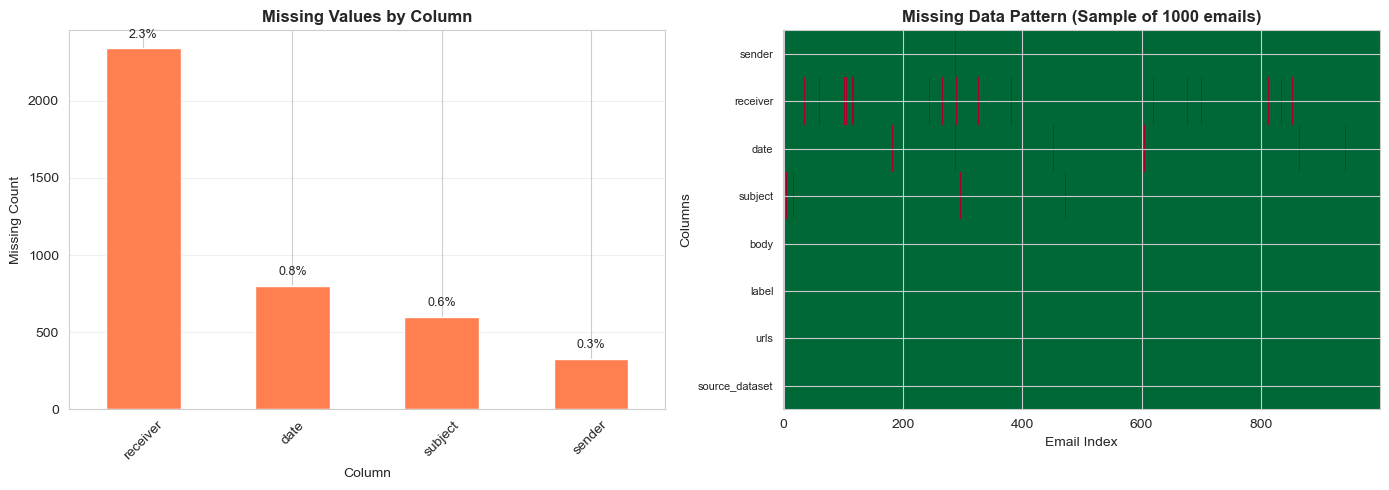

In [41]:
# OVERALL MISSING DATA SUMMARY
# Count missing values for each column
missing_summary = pd.DataFrame({
    'Column': email_df.columns,
    'Missing_Count': email_df.isnull().sum(),
    'Missing_Percentage': (email_df.isnull().sum() / len(email_df) * 100).round(2),
    'Data_Type': email_df.dtypes
})

# Sort by missing count
missing_summary = missing_summary.sort_values('Missing_Count', ascending=False)

print("\nMissing Values by Column:")
print(missing_summary.to_string(index=False))

# Total missing values
total_missing = email_df.isnull().sum().sum()
total_cells = email_df.shape[0] * email_df.shape[1]
print(f"\nTotal missing values: {total_missing:,} out of {total_cells:,} cells ({total_missing/total_cells*100:.2f}%)")

# Visualize missing data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of missing counts
missing_data = email_df.isnull().sum()[email_df.isnull().sum() > 0].sort_values(ascending=False)
if len(missing_data) > 0:
    missing_data.plot(kind='bar', ax=axes[0], color='coral')
    axes[0].set_title('Missing Values by Column', fontweight='bold')
    axes[0].set_xlabel('Column')
    axes[0].set_ylabel('Missing Count')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)

    # Add percentage labels
    for i, (col, count) in enumerate(missing_data.items()):
        pct = count / len(email_df) * 100
        axes[0].text(i, count + 50, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# Heatmap showing missing data pattern
import numpy as np
sample_size = min(1000, len(email_df))
sample_df = email_df.sample(sample_size, random_state=42)
missing_matrix = sample_df.isnull().astype(int)

axes[1].imshow(missing_matrix.T, cmap='RdYlGn_r', aspect='auto', interpolation='nearest')
axes[1].set_title(f'Missing Data Pattern (Sample of {sample_size} emails)', fontweight='bold')
axes[1].set_xlabel('Email Index')
axes[1].set_ylabel('Columns')
axes[1].set_yticks(range(len(email_df.columns)))
axes[1].set_yticklabels(email_df.columns, fontsize=8)

plt.tight_layout()
plt.show()


In [42]:

#DETAILED ANALYSIS PER COLUMN
for col in email_df.columns:
    null_count = email_df[col].isnull().sum()

    if null_count > 0:
        print(f"\n{'-'*70}")
        print(f"Column: {col}")
        print(f"{'-'*70}")
        print(f"Missing count: {null_count:,} ({null_count/len(email_df)*100:.2f}%)")

        # Show distribution by label
        missing_by_label = email_df[email_df[col].isnull()]['label'].value_counts().sort_index()
        print(f"\nMissing values by label:")
        for label, count in missing_by_label.items():
            pct = count / null_count * 100
            print(f"  Label {label} ({'Phishing' if label == 1 else 'Legitimate'}): {count:,} ({pct:.1f}%)")

        # Show distribution by source
        missing_by_source = email_df[email_df[col].isnull()]['source_dataset'].value_counts()
        print(f"\nMissing values by source dataset:")
        for source, count in missing_by_source.head(5).items():
            pct = count / null_count * 100
            print(f"  {source}: {count:,} ({pct:.1f}%)")

        # Sample rows with missing values
        print(f"\nSample rows with missing {col} (first 5):")
        sample_missing = email_df[email_df[col].isnull()].head(5)
        display_cols = [c for c in ['subject', 'sender', 'receiver', 'label', 'source_dataset'] if c != col]
        print(sample_missing[display_cols].to_string(index=False))


----------------------------------------------------------------------
Column: sender
----------------------------------------------------------------------
Missing count: 327 (0.33%)

Missing values by label:
  Label 0 (Legitimate): 2 (0.6%)
  Label 1 (Phishing): 325 (99.4%)

Missing values by source dataset:
  Nigerian_5: 326 (99.7%)
  Nazario_5: 1 (0.3%)

Sample rows with missing sender (first 5):
                                    subject           receiver  label source_dataset
Re: Where does one get ProIcon for the Mac?         icon-group      0      Nazario_5
                                        NaN                NaN      0     Nigerian_5
             WANTED FOR FRAUD: Fawwaz Ulaby           oshea@UM      1     Nigerian_5
                          please contact me ga_mm1@zwallet.com      1     Nigerian_5
                                   TRANSFER                R@E      1     Nigerian_5

----------------------------------------------------------------------
Column: recei

In [43]:
# EMPTY STRING ANALYSIS (NOT NULL BUT EMPTY)
# Check for empty strings in text columns
text_columns = ['sender', 'receiver', 'subject', 'body']

empty_summary = {}
for col in text_columns:
    if col in email_df.columns:
        # Check for empty or whitespace-only strings
        empty_count = (email_df[col].fillna('').str.strip() == '').sum()
        empty_summary[col] = empty_count

print("\nEmpty/Whitespace-only strings by column:")
for col, count in empty_summary.items():
    pct = count / len(email_df) * 100
    print(f"  {col}: {count:,} ({pct:.2f}%)")

# Find rows with empty strings (not null)
for col in text_columns:
    if col in email_df.columns:
        not_null_but_empty = (email_df[col].notna()) & (email_df[col].str.strip() == '')
        count = not_null_but_empty.sum()

        if count > 0:
            print(f"\n{col}: {count:,} rows are not null but empty/whitespace")
            print("Sample:")
            print(email_df[not_null_but_empty][['subject', 'sender', 'receiver', 'label']].head(3).to_string(index=False))


Empty/Whitespace-only strings by column:
  sender: 327 (0.33%)
  receiver: 2,340 (2.34%)
  subject: 601 (0.60%)
  body: 1 (0.00%)

subject: 1 rows are not null but empty/whitespace
Sample:
subject                     sender                  receiver  label
        �� G <gnome460@dion.ne.jp> smiles@flax9.uwaterloo.ca      1

body: 1 rows are not null but empty/whitespace
Sample:
            subject                            sender                    receiver  label
Information for you "Dr. Plewt" <farwood944@awod.com> <optin@dogma.slashnull.org>      1


In [44]:
# COMBINED MISSING ANALYSIS (NULL OR EMPTY)
combined_missing = {}
for col in text_columns:
    if col in email_df.columns:
        # Count both null and empty
        null_or_empty = email_df[col].isnull() | (email_df[col].str.strip() == '')
        combined_missing[col] = null_or_empty.sum()

print("\nNull OR Empty values by column:")
for col, count in combined_missing.items():
    pct = count / len(email_df) * 100
    print(f"  {col}: {count:,} ({pct:.2f}%)")


Null OR Empty values by column:
  sender: 327 (0.33%)
  receiver: 2,340 (2.34%)
  subject: 601 (0.60%)
  body: 1 (0.00%)


In [45]:
# ROWS WITH MULTIPLE MISSING VALUES

# Count missing values per row
missing_per_row = email_df.isnull().sum(axis=1)

print("\nDistribution of missing values per row:")
missing_dist = missing_per_row.value_counts().sort_index()
for num_missing, count in missing_dist.items():
    if num_missing > 0:
        pct = count / len(email_df) * 100
        print(f"  {num_missing} missing value(s): {count:,} rows ({pct:.2f}%)")

# Rows with 2+ missing values
multi_missing = email_df[missing_per_row >= 2]
print(f"\nRows with 2+ missing values: {len(multi_missing):,} ({len(multi_missing)/len(email_df)*100:.2f}%)")

if len(multi_missing) > 0:
    print("\nSample rows with multiple missing values:")
    print(multi_missing[['sender', 'receiver', 'date', 'subject', 'label', 'source_dataset']].head(5).to_string(index=False))


Distribution of missing values per row:
  1 missing value(s): 3,023 rows (3.02%)
  2 missing value(s): 473 rows (0.47%)
  3 missing value(s): 30 rows (0.03%)
  4 missing value(s): 2 rows (0.00%)

Rows with 2+ missing values: 505 (0.50%)

Sample rows with multiple missing values:
                         sender receiver                      date subject  label source_dataset
             i.gxs@massey.ac.nz      NaN 2008-08-07 14:22:47+13:00     NaN      0        CEAS_08
gvcormac@teff16.cs.uwaterloo.ca      NaN 2008-08-07 20:01:36-04:00     NaN      1        CEAS_08
        c.r.suyivq@massey.ac.nz      NaN 2008-08-08 12:12:17+12:00     NaN      0        CEAS_08
           r.tpjiv@massey.ac.nz      NaN 2008-08-08 12:36:53+12:00     NaN      0        CEAS_08
        i.z.fovjez@massey.ac.nz      NaN 2008-08-08 13:59:08+12:00     NaN      0        CEAS_08


In [46]:
# CRITICAL MISSING DATA (BODY)

# Body should never be missing (it's our main feature)
body_missing = email_df['body'].isnull().sum()
body_empty = (email_df['body'].str.strip() == '').sum()

print(f"Body column - NULL values: {body_missing:,}")
print(f"Body column - Empty strings: {body_empty:,}")

if body_missing > 0 or body_empty > 0:
    print("\n⚠ WARNING: Body column has missing/empty values!")
    print("These rows should be removed as body is critical for phishing detection.")


Body column - NULL values: 0
Body column - Empty strings: 1

⚠ WARNING: Body column has missing/empty values!
These rows should be removed as body is critical for phishing detection.


In [47]:
# MISSING DATA PATTERNS BY SOURCE
# Create a summary of missing data by source
source_missing = []
for source in email_df['source_dataset'].unique():
    source_data = email_df[email_df['source_dataset'] == source]
    row = {
        'Source': source,
        'Total_Emails': len(source_data),
        'Missing_Sender': source_data['sender'].isnull().sum(),
        'Missing_Receiver': source_data['receiver'].isnull().sum(),
        'Missing_Date': source_data['date'].isnull().sum(),
        'Missing_Subject': source_data['subject'].isnull().sum(),
    }
    source_missing.append(row)

source_missing_df = pd.DataFrame(source_missing).sort_values('Total_Emails', ascending=False)
print("\nMissing data by source dataset:")
print(source_missing_df.to_string(index=False))


Missing data by source dataset:
     Source  Total_Emails  Missing_Sender  Missing_Receiver  Missing_Date  Missing_Subject
    TREC_07         50813               0               312           233              448
    CEAS_08         37313               0               436            15               28
SpamAssasin          4750               0               190            71               16
 Nigerian_5          4515             326              1302           476               59
    Nazario          1512               0                92             4                4
  Nazario_5          1135               1                 8             1               45


In [48]:
# DATETIME VALIDITY CHECK

if email_df['date'].dtype == 'object':
    print("Date column is still object type (string)")
    # Try to parse dates
    valid_dates = pd.to_datetime(email_df['date'], errors='coerce')
    invalid_dates = valid_dates.isnull() & email_df['date'].notna()
    print(f"Invalid date formats: {invalid_dates.sum():,}")
elif pd.api.types.is_datetime64_any_dtype(email_df['date']):
    nat_count = email_df['date'].isna().sum()
    print(f"Date column is datetime type")
    print(f"NaT (Not a Time) values: {nat_count:,} ({nat_count/len(email_df)*100:.2f}%)")

    # Show date range
    valid_dates = email_df['date'].dropna()
    if len(valid_dates) > 0:
        print(f"\nDate range:")
        print(f"  Earliest: {valid_dates.min()}")
        print(f"  Latest: {valid_dates.max()}")

Date column is still object type (string)
Invalid date formats: 96,726


In [49]:
# SUMMARY RECOMMENDATION
critical_cols = []
for col in ['body', 'label']:
    if col in email_df.columns:
        missing = email_df[col].isnull().sum()
        if missing > 0:
            critical_cols.append(f"  - {col}: {missing:,} missing")

if critical_cols:
    print("\n".join(critical_cols))
    print("  → ACTION: Remove these rows (no ML value without body/label)")
else:
    print("  ✓ No critical missing data")


  ✓ No critical missing data


## **KEY FINDINGS**

### **Missing Data Status:**
- Body & Label: 0% missing ✓
- Sender: 327 missing (0.33%)
- Subject: 602 missing (0.60%)
- Receiver: 2,340 missing (2.34%)
- Date: 817 missing + 96.7% corrupted

### **Column Relevance for PAC:**
**Essential:** Body, Subject, Sender, Label
**Irrelevant:** Receiver (routing metadata), Date (temporal data, corrupted)
**Keep but handle:** URLs (fill with ""), source_dataset (metadata) - might need it later

### **Impact:**
- Dropping irrelevant columns first saves 2,617 emails
- Final retention: ~99,109 emails (99.1%)


## **ACTION PLAN**

1. **Drop columns:** receiver, date (irrelevant for PAC training)
2. **Remove rows:** Where sender, subject, OR body is missing/empty (~929 rows)
3. **Fill URLs:** Replace null/empty with "" for consistency

**Result:** Clean dataset with only relevant features, ready for PAC training.

## MISSING DATA HANDLING: DROP COLUMNS THEN AGGRESSIVE CLEAN

In [50]:
# Store initial state
initial_count = len(email_df)
initial_cols = email_df.shape[1]

print(f"\nStarting with: {initial_count:,} emails × {initial_cols} columns")
print(f"Columns: {list(email_df.columns)}")


Starting with: 100,038 emails × 8 columns
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'source_dataset']


#### DROP IRRELEVANT COLUMNS

In [51]:
# Columns to drop (irrelevant for PAC training)
columns_to_drop = ['receiver', 'date']

print(f"\nDropping columns: {columns_to_drop}")

for col in columns_to_drop:
    if col in email_df.columns:
        missing_count = email_df[col].isnull().sum()
        print(f"  - {col}: {missing_count:,} missing values")

# Drop the columns
email_df = email_df.drop(columns=columns_to_drop, errors='ignore')

print(f"\n✓ Dropped {len(columns_to_drop)} columns")
print(f"Remaining columns: {list(email_df.columns)}")


Dropping columns: ['receiver', 'date']
  - receiver: 2,340 missing values
  - date: 800 missing values

✓ Dropped 2 columns
Remaining columns: ['sender', 'subject', 'body', 'label', 'urls', 'source_dataset']


#### FILL EMPTY/NULL URLs WITH EMPTY STRING

In [52]:
# Check current state of urls column
print(f"\nURLs column dtype: {email_df['urls'].dtype}")
print(f"\nURLs column value counts:")
print(email_df['urls'].value_counts(dropna=False))

urls_null = email_df['urls'].isnull().sum()
print(f"\nURLs column status:")
print(f"  NULL values: {urls_null:,}")

# Fill null values with False (since it's a boolean column)
email_df['urls'] = email_df['urls'].fillna(False)

print(f"\nFilled all NULL URLs with False")

# Verify
urls_null_after = email_df['urls'].isnull().sum()
print(f"NULL values after fill: {urls_null_after:,}")
print(f"\nFinal value counts:")
print(email_df['urls'].value_counts(dropna=False))


URLs column dtype: bool

URLs column value counts:
urls
True    100038
Name: count, dtype: int64

URLs column status:
  NULL values: 0

Filled all NULL URLs with False
NULL values after fill: 0

Final value counts:
urls
True    100038
Name: count, dtype: int64


#### AGGRESSIVE CLEAN - REMOVE ROWS WITH MISSING SENDER, SUBJECT, OR BODY

In [53]:
# Check missing values in critical columns
critical_columns = ['sender', 'subject', 'body']
missing_summary = {}

for col in critical_columns:
    null_count = email_df[col].isnull().sum()
    empty_count = (email_df[col].notna() & (email_df[col].str.strip() == '')).sum()
    total_missing = null_count + empty_count
    missing_summary[col] = total_missing

    print(f"\n  {col}:")
    print(f"    NULL: {null_count:,}")
    print(f"    Empty strings: {empty_count:,}")
    print(f"    Total missing: {total_missing:,} ({total_missing/len(email_df)*100:.2f}%)")

# Identify rows to remove (missing sender, subject, OR body)
rows_to_remove = (
    email_df['sender'].isnull() | (email_df['sender'].str.strip() == '') |
    email_df['subject'].isnull() | (email_df['subject'].str.strip() == '') |
    email_df['body'].isnull() | (email_df['body'].str.strip() == '')
)

rows_to_remove_count = rows_to_remove.sum()

print(f"\n{'-'*70}")
print(f"Total rows to remove (ANY missing in sender/subject/body): {rows_to_remove_count:,}")
print(f"Percentage of dataset: {rows_to_remove_count/len(email_df)*100:.2f}%")

# Show distribution of removed rows by label
print(f"\nRemoved rows by label:")
removed_by_label = email_df[rows_to_remove]['label'].value_counts().sort_index()
for label, count in removed_by_label.items():
    pct = count / rows_to_remove_count * 100
    print(f"  Label {label} ({'Phishing' if label == 1 else 'Legitimate'}): {count:,} ({pct:.1f}%)")

# Show distribution by source
print(f"\nRemoved rows by source dataset:")
removed_by_source = email_df[rows_to_remove]['source_dataset'].value_counts().head(5)
for source, count in removed_by_source.items():
    pct = count / rows_to_remove_count * 100
    print(f"  {source}: {count:,} ({pct:.1f}%)")

# Remove rows
email_df = email_df[~rows_to_remove]

print(f"\n✓ Removed {rows_to_remove_count:,} rows with missing critical data")


  sender:
    NULL: 327
    Empty strings: 0
    Total missing: 327 (0.33%)

  subject:
    NULL: 600
    Empty strings: 1
    Total missing: 601 (0.60%)

  body:
    NULL: 0
    Empty strings: 1
    Total missing: 1 (0.00%)

----------------------------------------------------------------------
Total rows to remove (ANY missing in sender/subject/body): 923
Percentage of dataset: 0.92%

Removed rows by label:
  Label 0 (Legitimate): 88 (9.5%)
  Label 1 (Phishing): 835 (90.5%)

Removed rows by source dataset:
  TREC_07: 449 (48.6%)
  Nigerian_5: 379 (41.1%)
  Nazario_5: 46 (5.0%)
  CEAS_08: 28 (3.0%)
  SpamAssasin: 17 (1.8%)

✓ Removed 923 rows with missing critical data


### ANALYZING: BODIES WITH URLs BUT URL COLUMN SAYS 0

In [54]:
# Comprehensive URL pattern covering ALL common URL formats
url_patterns = [
    r'https?://[^\s<>\"\'\)]+',           # http:// or https://
    r'ftp://[^\s<>\"\'\)]+',              # ftp://
    r'ftps://[^\s<>\"\'\)]+',             # ftps://
    r'sftp://[^\s<>\"\'\)]+',             # sftp://
    r'www\.[^\s<>\"\'\)]+',               # www.
    r'file://[^\s<>\"\'\)]+',             # file://
    r'ssh://[^\s<>\"\'\)]+',              # ssh://
    r'telnet://[^\s<>\"\'\)]+',           # telnet://
    r'git://[^\s<>\"\'\)]+',              # git://
    r'svn://[^\s<>\"\'\)]+',              # svn://
    r'mailto:[^\s<>\"\'\)]+',             # mailto:
    r'news:[^\s<>\"\'\)]+',               # news:
    r'nntp://[^\s<>\"\'\)]+',             # nntp://
    r'irc://[^\s<>\"\'\)]+',              # irc://
    r'webcal://[^\s<>\"\'\)]+',           # webcal://
    # Domain-like patterns (e.g., example.com, site.co.uk)
    r'\b[a-zA-Z0-9][-a-zA-Z0-9]*\.[a-zA-Z]{2,}(?:\.[a-zA-Z]{2,})?\b(?:/[^\s<>\"\'\)]*)?'
]

In [55]:
# COMPREHENSIVE URL DETECTION IN BODY

# Combine all patterns with OR operator
comprehensive_url_pattern = '|'.join(url_patterns)


# Detect URLs in body with comprehensive pattern
email_df['body_has_urls'] = email_df['body'].str.contains(
    comprehensive_url_pattern,
    case=False,
    regex=True,
    na=False
)

# Convert URL column to binary for comparison
def parse_url_to_binary(value):
    if pd.isna(value) or value == '' or value == '0' or value == '[]':
        return 0
    else:
        return 1

email_df['urls_binary'] = email_df['urls'].apply(parse_url_to_binary)


In [56]:
# FIND MISMATCHES: Body HAS URLs but Column says 0

# Body has URLs BUT urls column says 0
mismatch = (email_df['body_has_urls'] == True) & (email_df['urls_binary'] == 0)
mismatch_count = mismatch.sum()

print(f"\n🔍 Emails with URLs in body BUT url column = 0:")
print(f"   Count: {mismatch_count:,} ({mismatch_count/len(email_df)*100:.2f}%)")

if mismatch_count > 0:
    mismatch_df = email_df[mismatch]

    # Show distribution by label
    print(f"\nDistribution by label:")
    for label in [0, 1]:
        count = (mismatch_df['label'] == label).sum()
        pct = count / mismatch_count * 100
        label_name = 'Legitimate' if label == 0 else 'Phishing'
        print(f"  {label_name} (Label {label}): {count:,} ({pct:.1f}%)")

    # Show distribution by source
    print(f"\nDistribution by source dataset:")
    source_dist = mismatch_df['source_dataset'].value_counts().head(10)
    for source, count in source_dist.items():
        pct = count / mismatch_count * 100
        print(f"  {source}: {count:,} ({pct:.1f}%)")

    # Show detailed examples
    print("\n" + "="*70)
    print("DETAILED EXAMPLES (First 10)")
    print("="*70)

    for i, (idx, row) in enumerate(mismatch_df.head(10).iterrows(), 1):
        # Extract URLs from body using comprehensive pattern
        urls_found = re.findall(comprehensive_url_pattern, row['body'], re.IGNORECASE)

        # Categorize URLs by type
        url_types = {
            'http/https': [],
            'www': [],
            'ftp/sftp': [],
            'mailto': [],
            'plain domains': [],
            'other': []
        }

        for url in urls_found:
            if url.startswith(('http://', 'https://')):
                url_types['http/https'].append(url)
            elif url.startswith('www.'):
                url_types['www'].append(url)
            elif url.startswith(('ftp://', 'ftps://', 'sftp://')):
                url_types['ftp/sftp'].append(url)
            elif url.startswith('mailto:'):
                url_types['mailto'].append(url)
            elif '.' in url and not url.startswith(('http', 'ftp', 'www', 'mailto')):
                url_types['plain domains'].append(url)
            else:
                url_types['other'].append(url)

        print(f"\n{'-'*70}")
        print(f"Example {i}:")
        print(f"  Subject: {row['subject'][:70] if pd.notna(row['subject']) else 'No Subject'}")
        print(f"  Label: {row['label']} ({'Phishing' if row['label'] == 1 else 'Legitimate'})")
        print(f"  Source: {row['source_dataset']}")
        print(f"  URL column value: '{row['urls']}'")
        print(f"  Total URLs found: {len(urls_found)}")

        # Show URLs by type
        print(f"  URLs by type:")
        for url_type, type_urls in url_types.items():
            if type_urls:
                print(f"    {url_type}: {len(type_urls)} URL(s)")
                for url in type_urls[:2]:  # Show first 2 of each type
                    print(f"      → {url}")
                if len(type_urls) > 2:
                    print(f"      ... and {len(type_urls) - 2} more")

        print(f"  Body preview (first 300 chars):")
        print(f"    {row['body'][:300]}...")

    # Summary statistics
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70)

    # Count URLs per email in mismatched group
    url_counts = []
    url_type_counts = {
        'http/https': 0,
        'www': 0,
        'ftp': 0,
        'mailto': 0,
        'plain domains': 0,
        'other': 0
    }

    for body in mismatch_df['body']:
        urls_found = re.findall(comprehensive_url_pattern, body, re.IGNORECASE)
        url_counts.append(len(urls_found))

        # Count by type
        for url in urls_found:
            if url.startswith(('http://', 'https://')):
                url_type_counts['http/https'] += 1
            elif url.startswith('www.'):
                url_type_counts['www'] += 1
            elif url.startswith(('ftp://', 'ftps://', 'sftp://')):
                url_type_counts['ftp'] += 1
            elif url.startswith('mailto:'):
                url_type_counts['mailto'] += 1
            elif '.' in url and not url.startswith(('http', 'ftp', 'www', 'mailto')):
                url_type_counts['plain domains'] += 1
            else:
                url_type_counts['other'] += 1

    url_counts_series = pd.Series(url_counts)
    print(f"\nURL count per email in mismatched group:")
    print(f"  Min: {url_counts_series.min()}")
    print(f"  Max: {url_counts_series.max()}")
    print(f"  Mean: {url_counts_series.mean():.2f}")
    print(f"  Median: {url_counts_series.median():.0f}")

    print(f"\nURL types found in mismatched emails:")
    for url_type, count in url_type_counts.items():
        if count > 0:
            pct = count / sum(url_type_counts.values()) * 100
            print(f"  {url_type}: {count:,} ({pct:.1f}%)")

    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Distribution by label
    label_dist = mismatch_df['label'].value_counts().sort_index()
    axes[0, 0].bar(['Legitimate (0)', 'Phishing (1)'], label_dist.values, color=['#66b3ff', '#ff9999'])
    axes[0, 0].set_title('Mismatched Emails by Label', fontweight='bold')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(label_dist.values):
        axes[0, 0].text(i, v + 10, f'{v:,}', ha='center', va='bottom', fontweight='bold')

    # Plot 2: URL count distribution
    axes[0, 1].hist(url_counts, bins=30, edgecolor='black', alpha=0.7, color='coral')
    axes[0, 1].set_title('Distribution of URL Count in Mismatched Emails', fontweight='bold')
    axes[0, 1].set_xlabel('Number of URLs in Body')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(axis='y', alpha=0.3)

    # Plot 3: URL types breakdown
    url_type_data = pd.Series({k: v for k, v in url_type_counts.items() if v > 0})
    url_type_data.plot(kind='bar', ax=axes[1, 0], color='skyblue')
    axes[1, 0].set_title('URL Types in Mismatched Emails', fontweight='bold')
    axes[1, 0].set_xlabel('URL Type')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(axis='y', alpha=0.3)

    # Plot 4: Source distribution
    top_sources = mismatch_df['source_dataset'].value_counts().head(8)
    top_sources.plot(kind='barh', ax=axes[1, 1], color='lightgreen')
    axes[1, 1].set_title('Top Sources with Mismatched Emails', fontweight='bold')
    axes[1, 1].set_xlabel('Count')
    axes[1, 1].set_ylabel('Source Dataset')
    axes[1, 1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("\nNO MISMATCHES FOUND!")
    print("   All emails with URLs in body have url column = 1")

# Clean up temporary columns
email_df = email_df.drop(['body_has_urls', 'urls_binary'], axis=1)



🔍 Emails with URLs in body BUT url column = 0:
   Count: 0 (0.00%)

NO MISMATCHES FOUND!
   All emails with URLs in body have url column = 1


### COMPREHENSIVE URL DETECTION IN EMAIL BODIES

In [57]:
# COMPREHENSIVE URL DETECTION IN EMAIL BODIES

# Detect URLs in body
print("\nScanning all email bodies...")
email_df['body_has_urls'] = email_df['body'].str.contains(
    comprehensive_url_pattern,
    case=False,
    regex=True,
    na=False
)

# Count URLs
bodies_with_urls = email_df['body_has_urls'].sum()
bodies_without_urls = (~email_df['body_has_urls']).sum()

print(f"\nDetection results:")
print(f"  Bodies WITH URLs: {bodies_with_urls:,} ({bodies_with_urls/len(email_df)*100:.2f}%)")
print(f"  Bodies WITHOUT URLs: {bodies_without_urls:,} ({bodies_without_urls/len(email_df)*100:.2f}%)")



Scanning all email bodies...

Detection results:
  Bodies WITH URLs: 78,148 (78.85%)
  Bodies WITHOUT URLs: 20,967 (21.15%)


In [58]:
# SAMPLE URL DETECTION
# Extract and show sample URLs
sample_emails_with_urls = email_df[email_df['body_has_urls']].sample(min(5, bodies_with_urls), random_state=42)

print("\nSample emails and their detected URLs:")
for i, (idx, row) in enumerate(sample_emails_with_urls.iterrows(), 1):
    urls_found = re.findall(comprehensive_url_pattern, row['body'], re.IGNORECASE)
    print(f"\n{i}. Subject: {str(row['subject'])[:60]}...")
    print(f"   Label: {row['label']} ({'Phishing' if row['label'] == 1 else 'Legitimate'})")
    print(f"   URLs found ({len(urls_found)}): {urls_found[:3]}")  # Show first 3


Sample emails and their detected URLs:

1. Subject: Re: Array of Array refs...
   Label: 0 (Legitimate)
   URLs found (6): ['screenlight.com', 'comp.lang.perl', 'perl.org']

2. Subject: Wed Like to Present You a Special Offer...
   Label: 1 (Phishing)
   URLs found (2): ['http://rshezle.sevenarrive.hk/?264299177698', 'http://rshezle.sevenarrive.hk/?264299177698']

3. Subject: Odell FILE...
   Label: 1 (Phishing)
   URLs found (1): ['price.See']

4. Subject: Don't be left out, join millions of men in the revolution...
   Label: 1 (Phishing)
   URLs found (1): ['http://www.sargist.com/']

5. Subject: The bigger tool...
   Label: 1 (Phishing)
   URLs found (1): ['answerdry.com']


In [59]:
# BACKUP ORIGINAL URL COLUMN

# Create backup of original URL column
email_df['urls_original'] = email_df['urls'].copy()

print(f"\n✓ Original URL column backed up as 'urls_original'")
print(f"  Original unique values: {email_df['urls_original'].nunique()}")



✓ Original URL column backed up as 'urls_original'
  Original unique values: 1


In [60]:
# UPDATE URL COLUMN
print(f"\nBefore update:")
print(f"  Column type: {email_df['urls'].dtype}")
print(f"  Unique values: {email_df['urls'].nunique()}")
print(f"  Sample values: {email_df['urls'].head(10).tolist()}")

# Replace URL column with binary based on comprehensive body detection
# 1 = has URLs, 0 = no URLs
email_df['urls'] = email_df['body_has_urls'].astype(int)

print(f"\nAfter update:")
print(f"  Column type: {email_df['urls'].dtype}")
print(f"  Unique values: {email_df['urls'].nunique()}")
print(f"  Sample values: {email_df['urls'].head(10).tolist()}")



Before update:
  Column type: bool
  Unique values: 1
  Sample values: [True, True, True, True, True, True, True, True, True, True]

After update:
  Column type: int64
  Unique values: 2
  Sample values: [1, 1, 1, 1, 0, 0, 1, 1, 1, 1]


In [61]:
# VERIFY UPDATE

# Check for null values
null_count = email_df['urls'].isnull().sum()
print(f"\nNull values: {null_count}")

# Show distribution
print(f"\nFinal URL column distribution:")
url_distribution = email_df['urls'].value_counts().sort_index()
for value, count in url_distribution.items():
    pct = count / len(email_df) * 100
    label = "No URLs" if value == 0 else "Has URLs"
    print(f"  {value} ({label}): {count:,} ({pct:.2f}%)")


Null values: 0

Final URL column distribution:
  0 (No URLs): 20,967 (21.15%)
  1 (Has URLs): 78,148 (78.85%)


In [62]:
# COMPARE BEFORE vs AFTER

# Parse original column to binary for comparison
def parse_to_binary(value):
    if pd.isna(value) or value == '' or value == '0' or value == '[]':
        return 0
    else:
        return 1

email_df['urls_original_binary'] = email_df['urls_original'].apply(parse_to_binary)

# Calculate changes
changed = (email_df['urls_original_binary'] != email_df['urls']).sum()
unchanged = (email_df['urls_original_binary'] == email_df['urls']).sum()

print(f"\nComparison:")
print(f"  Unchanged: {unchanged:,} ({unchanged/len(email_df)*100:.2f}%)")
print(f"  Changed: {changed:,} ({changed/len(email_df)*100:.2f}%)")

# Show what changed
changed_0_to_1 = ((email_df['urls_original_binary'] == 0) & (email_df['urls'] == 1)).sum()
changed_1_to_0 = ((email_df['urls_original_binary'] == 1) & (email_df['urls'] == 0)).sum()

print(f"\nChanges breakdown:")
print(f"  0 → 1 (added URLs): {changed_0_to_1:,}")
print(f"  1 → 0 (removed URLs): {changed_1_to_0:,}")

if changed_0_to_1 > 0:
    print(f"\nThese {changed_0_to_1:,} emails now detected with comprehensive pattern:")
    print(f"  → Includes www., ftp://, plain domains, mailto:, etc.")

if changed_1_to_0 > 0:
    print(f"\nThese {changed_1_to_0:,} emails no longer have URLs:")
    print(f"  → URLs were in HTML tags that we removed")


Comparison:
  Unchanged: 78,148 (78.85%)
  Changed: 20,967 (21.15%)

Changes breakdown:
  0 → 1 (added URLs): 0
  1 → 0 (removed URLs): 20,967

These 20,967 emails no longer have URLs:
  → URLs were in HTML tags that we removed


In [63]:
# DISTRIBUTION BY LABEL
for label in [0, 1]:
    label_data = email_df[email_df['label'] == label]
    has_urls = (label_data['urls'] == 1).sum()
    no_urls = (label_data['urls'] == 0).sum()
    total = len(label_data)

    label_name = 'Legitimate' if label == 0 else 'Phishing'
    print(f"\n{label_name} (Label {label}): {total:,} emails")
    print(f"  Has URLs (1): {has_urls:,} ({has_urls/total*100:.2f}%)")
    print(f"  No URLs (0): {no_urls:,} ({no_urls/total*100:.2f}%)")


Legitimate (Label 0): 42,716 emails
  Has URLs (1): 36,792 (86.13%)
  No URLs (0): 5,924 (13.87%)

Phishing (Label 1): 56,399 emails
  Has URLs (1): 41,356 (73.33%)
  No URLs (0): 15,043 (26.67%)


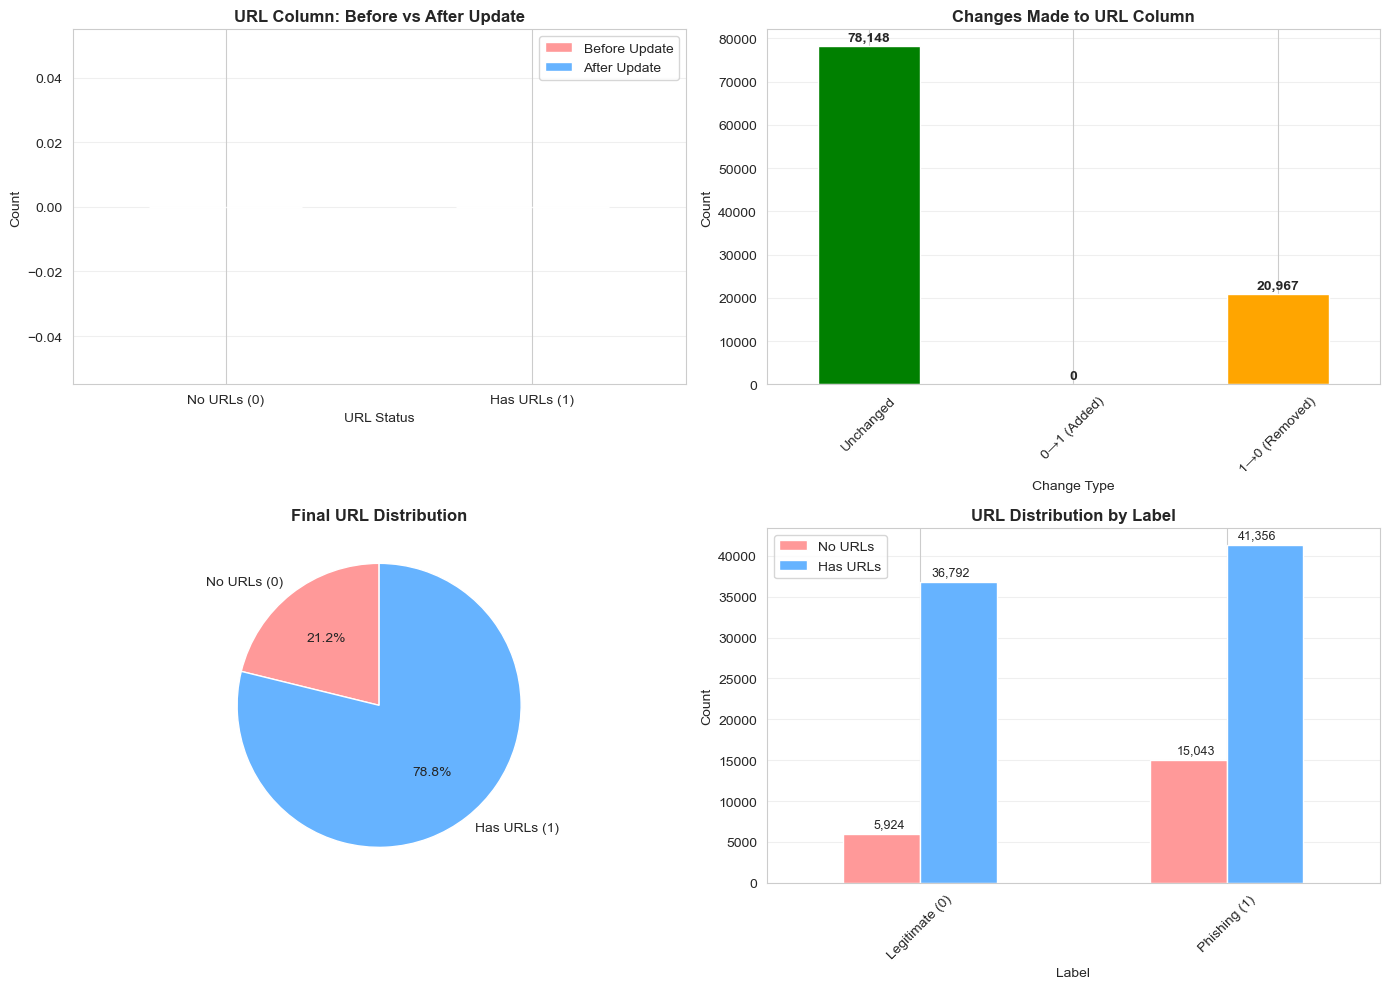

In [64]:
# VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Before vs After
before_dist = email_df['urls_original_binary'].value_counts().sort_index()
after_dist = email_df['urls'].value_counts().sort_index()

comparison_data = pd.DataFrame({
    'Before Update': before_dist,
    'After Update': after_dist
}, index=['No URLs (0)', 'Has URLs (1)'])

comparison_data.plot(kind='bar', ax=axes[0, 0], color=['#ff9999', '#66b3ff'])
axes[0, 0].set_title('URL Column: Before vs After Update', fontweight='bold')
axes[0, 0].set_xlabel('URL Status')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Add count labels
for i, (col_name, values) in enumerate(comparison_data.items()):
    for j, value in enumerate(values):
        axes[0, 0].text(j + (i-0.5)*0.2, value + 500, f'{value:,}',
                       ha='center', va='bottom', fontsize=9)

# Plot 2: Changes breakdown
changes_data = pd.Series({
    'Unchanged': unchanged,
    '0→1 (Added)': changed_0_to_1,
    '1→0 (Removed)': changed_1_to_0
})
changes_data.plot(kind='bar', ax=axes[0, 1], color=['green', 'blue', 'orange'])
axes[0, 1].set_title('Changes Made to URL Column', fontweight='bold')
axes[0, 1].set_xlabel('Change Type')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Add count labels
for i, (label, value) in enumerate(changes_data.items()):
    axes[0, 1].text(i, value + 500, f'{value:,}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Final distribution pie chart
axes[1, 0].pie(after_dist, labels=['No URLs (0)', 'Has URLs (1)'],
               autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff'])
axes[1, 0].set_title('Final URL Distribution', fontweight='bold')

# Plot 4: By label
url_by_label = email_df.groupby(['label', 'urls']).size().unstack(fill_value=0)
url_by_label.plot(kind='bar', ax=axes[1, 1], color=['#ff9999', '#66b3ff'])
axes[1, 1].set_title('URL Distribution by Label', fontweight='bold')
axes[1, 1].set_xlabel('Label')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xticklabels(['Legitimate (0)', 'Phishing (1)'], rotation=45)
axes[1, 1].legend(['No URLs', 'Has URLs'])
axes[1, 1].grid(axis='y', alpha=0.3)

# Add count labels
for i, label in enumerate([0, 1]):
    for j, url_val in enumerate([0, 1]):
        value = url_by_label.loc[label, url_val]
        axes[1, 1].text(i + (j-0.5)*0.2, value + 500, f'{value:,}',
                       ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [65]:
# CLEANUP TEMPORARY COLUMNS

# Drop temporary columns
email_df = email_df.drop(['body_has_urls', 'urls_original_binary'], axis=1)

print(f"\n✓ Dropped temporary columns: 'body_has_urls', 'urls_original_binary'")
print(f"✓ Kept 'urls_original' as backup")


✓ Dropped temporary columns: 'body_has_urls', 'urls_original_binary'
✓ Kept 'urls_original' as backup


## Final dataset cleaning
* Removing noise on the body and subject
* converts to lowercase and normalize white spaces

In [66]:
class EmailBodyCleaner:
    """
    Email body cleaner that removes noise while preserving URLs.
    KEEPS: !, ?, URLs, original case (extract features before lowercasing)
    REMOVES: ALL emojis, symbols, special chars dynamically using Unicode categories
    """

    def __init__(self):
        # Comprehensive URL patterns for protection
        self.url_patterns = url_patterns

        # Combined pattern for efficient matching
        self.combined_url_pattern = '|'.join(f'({pattern})' for pattern in self.url_patterns)

        # Email pattern
        self.email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'

        # Placeholders
        self.url_placeholder = "___URL_PLACEHOLDER_{}___ "
        self.email_placeholder = "___EMAIL_PLACEHOLDER_{}___ "

    def _protect_urls_and_emails(self, text):
        """
        Replace URLs and emails with placeholders to protect them during cleaning
        Returns: (protected_text, url_map, email_map)
        """
        url_map = {}
        email_map = {}

        # Find and protect URLs using combined pattern
        urls = re.findall(self.combined_url_pattern, text)
        # Flatten tuples from grouped patterns and filter empty strings
        urls = [url for url_tuple in urls for url in url_tuple if url]

        for i, url in enumerate(urls):
            placeholder = self.url_placeholder.format(i)
            url_map[placeholder.strip()] = url
            text = text.replace(url, placeholder, 1)

        # Find and protect email addresses
        emails = re.findall(self.email_pattern, text)
        for i, email in enumerate(emails):
            placeholder = self.email_placeholder.format(i)
            email_map[placeholder.strip()] = email
            text = text.replace(email, placeholder, 1)

        return text, url_map, email_map

    def _restore_urls_and_emails(self, text, url_map, email_map):
        """Restore protected URLs and emails"""
        for placeholder, url in url_map.items():
            text = text.replace(placeholder, url)
        for placeholder, email in email_map.items():
            text = text.replace(placeholder, email)
        return text

    def _remove_noise_patterns(self, text):
        """
        Remove identified noise patterns
        All removals use SPACE to prevent word concatenation

        KEEPS: !, ?, URLs (protected), original case
        REMOVES: HTML, headers, footers, encoding artifacts
        """

        # SEPARATOR PATTERNS - Replace with space
        text = re.sub(r'[>=+\-*_~]{10,}', ' ', text)
        text = re.sub(r'>\s*[=+\-]+\s*>', ' ', text)

        # QUOTE MARKERS - Replace with space
        text = re.sub(r'^\s*>\s*', ' ', text, flags=re.MULTILINE)
        text = re.sub(r'^\s*>+\s*', ' ', text, flags=re.MULTILINE)
        text = re.sub(r'(?<=\n)>\s+', ' ', text)

        # TABLE BORDERS AND PIPES - Replace with space
        text = re.sub(r'\|{2,}', ' ', text)
        text = re.sub(r'^\s*\|[-\s|]+\|\s*$', ' ', text, flags=re.MULTILINE)
        text = re.sub(r'^\s*\+[-+=\s]+\+\s*$', ' ', text, flags=re.MULTILINE)

        # REPEATED DOTS - Replace with space
        text = re.sub(r'\.{4,}', ' ', text)

        # THREADING ARTIFACTS - Replace with space
        text = re.sub(r'You are receiving this (mail|email).*?because.*?(\n|$)', ' ', text, flags=re.IGNORECASE)
        text = re.sub(r'To unsubscribe.*?(\n|$)', ' ', text, flags=re.IGNORECASE)
        text = re.sub(r'Click here to unsubscribe.*?(\n|$)', ' ', text, flags=re.IGNORECASE)

        # UNSUBSCRIBE FOOTERS - Replace with space
        text = re.sub(r'\b(unsubscribe|opt-?out|remove\s+me)\b', ' ', text, flags=re.IGNORECASE)

        # REPLY HEADERS - Replace with space
        text = re.sub(r'On\s+.+?\s+wrote:\s*', ' ', text, flags=re.IGNORECASE)

        # COPYRIGHT NOTICES - Replace with space
        text = re.sub(r'©|\(c\)\s*\d{4}|copyright\s+\d{4}', ' ', text, flags=re.IGNORECASE)
        text = re.sub(r'All rights reserved\.?', ' ', text, flags=re.IGNORECASE)

        # HTML TAGS - Replace with space
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'&[a-z]+;|&#\d+;', ' ', text)

        # PRIVACY POLICY LINKS - Replace with space
        text = re.sub(r'\b(privacy\s+policy|terms\s+of\s+service)\b', ' ', text, flags=re.IGNORECASE)

        # EMAIL HEADERS - Replace with space
        text = re.sub(r'^(From|To|Subject|Date|Cc|Bcc):\s*', ' ', text, flags=re.MULTILINE)

        # FORWARDING HEADERS - Replace with space
        text = re.sub(r'-+\s*(Original Message|Forwarded Message)\s*-+', ' ', text, flags=re.IGNORECASE)

        # REPEATED COLONS - Replace with space
        text = re.sub(r':{3,}', ' ', text)

        # MIME HEADERS - Replace with space
        text = re.sub(r'^(Content-Type|Content-Transfer-Encoding):', ' ', text, flags=re.MULTILINE)

        # ENCODING ISSUES - Replace with space
        text = re.sub(r'�+', ' ', text)
        text = re.sub(r'\?{5,}', ' ', text)

        return text

    def _remove_unicode_noise(self, text):
        """
        DYNAMIC removal of ALL emojis, symbols, and special characters
        using Unicode character categories.

        KEEPS ONLY:
        - Letters (all languages): L* categories
        - Numbers: N* categories
        - Spaces: Zs category
        - Explicit: ! ? and newlines
        - URL/Email placeholders: underscores in ___PLACEHOLDER___ format

        REMOVES:
        - So (Other symbols): emojis, arrows, geometric shapes
        - Sm (Math symbols): ±, ×, ÷, ≠, etc.
        - Sc (Currency symbols): €, £, ¥, ₹, etc.
        - Sk (Modifier symbols)
        - Po (Other punctuation): except ! and ?
        - Ps, Pe, Pi, Pf (Brackets, quotes)
        - Pd (Dashes): –, —, etc.
        - Pc (Connectors): except _ in placeholders
        - And all other non-letter/number Unicode categories
        """

        cleaned_chars = []

        for char in text:
            category = unicodedata.category(char)

            # KEEP these Unicode categories:
            if (category.startswith('L') or          # L* = All letters (Lu, Ll, Lt, Lm, Lo)
                category.startswith('N') or          # N* = All numbers (Nd, Nl, No)
                category == 'Zs' or                  # Zs = Space separator
                char in '!?\n' or                    # Explicit keeps
                char == '_'):                        # Underscore (for placeholders)

                cleaned_chars.append(char)
            else:
                # REMOVE everything else (emojis, symbols, special punctuation)
                # Replace with space to prevent word concatenation
                cleaned_chars.append(' ')

        return ''.join(cleaned_chars)

    def _normalize_whitespace(self, text):
        """
        Clean up excessive whitespace
        Remove multiple spaces, newlines, and trim
        """
        # Remove multiple spaces (including tabs)
        text = re.sub(r'[ \t]{2,}', ' ', text)

        # Remove multiple newlines (keep max 2 for paragraph breaks)
        text = re.sub(r'\n{3,}', '\n\n', text)

        # Remove trailing/leading whitespace from lines
        text = '\n'.join(line.strip() for line in text.split('\n'))

        # Remove empty lines
        text = '\n'.join(line for line in text.split('\n') if line.strip())

        # Final trim
        text = text.strip()

        return text

    def clean(self, text):
        """
        Main cleaning function

        Args:
            text (str): Raw email body text

        Returns:
            str: Cleaned text (noise removed, URLs preserved, ! and ? kept, CASE PRESERVED)
        """
        if pd.isna(text) or text == '':
            return ''

        text = str(text)

        # Step 1: Protect URLs and emails
        protected_text, url_map, email_map = self._protect_urls_and_emails(text)

        # Step 2: Remove noise patterns (uses spaces to prevent concatenation)
        cleaned_text = self._remove_noise_patterns(protected_text)

        # Step 3: DYNAMIC Unicode-based emoji and symbol removal
        cleaned_text = self._remove_unicode_noise(cleaned_text)

        # Step 4: Normalize whitespace (removes double spaces)
        cleaned_text = self._normalize_whitespace(cleaned_text)

        # Step 5: Restore URLs and emails
        final_text = self._restore_urls_and_emails(cleaned_text, url_map, email_map)

        # Step 6: DON'T convert to lowercase - preserve original case for feature extraction
        # final_text = final_text.lower()  # REMOVED - case preserved for uppercase ratio features

        return final_text

    def clean_dataframe(self, df, body_column='body'):
        """
        Clean email body column IN-PLACE (replaces original column)

        Args:
            df: DataFrame with email bodies
            body_column: Name of column containing body text (default: 'body')

        Returns:
            DataFrame with cleaned body column (replaced)
        """
        print(f"Cleaning '{body_column}' column...")
        print(f"Total emails: {len(df):,}")

        # Store original for statistics
        original_lengths = df[body_column].str.len()

        # Clean the column (replaces original)
        df[body_column] = df[body_column].apply(self.clean)

        # Show statistics
        cleaned_lengths = df[body_column].str.len()

        print(f"\nCleaning complete.")
        print(f"Average original length: {original_lengths.mean():.1f} chars")
        print(f"Average cleaned length: {cleaned_lengths.mean():.1f} chars")
        print(f"Reduction: {(1 - cleaned_lengths.mean() / original_lengths.mean()) * 100:.1f}%")

        return df

In [67]:
def clean_subject(subject):
    """
    Clean email subject by removing ALL special characters and noise dynamically.
    Uses Unicode categories to remove emojis and symbols.

    KEEPS ONLY: letters, numbers, !, ?, spaces, original case
    REMOVES: ALL emojis, symbols, special punctuation (dynamically)

    Args:
        subject (str): Raw email subject

    Returns:
        str: Cleaned subject text (CASE PRESERVED)
    """

    if pd.isna(subject) or subject == '':
        return ''

    subject = str(subject)
    cleaned = subject

    # Remove "Re:" and "Fwd:" prefixes (replace with space)
    cleaned = re.sub(r'^(Re|Fwd|RE|FWD):\s*', '', cleaned)

    # Remove square brackets and contents (replace with space)
    cleaned = re.sub(r'\[.*?\]', ' ', cleaned)

    # Remove parentheses and contents (replace with space)
    cleaned = re.sub(r'\(.*?\)', ' ', cleaned)

    # ========================================================================
    # DYNAMIC UNICODE-BASED CHARACTER FILTERING
    # ========================================================================

    cleaned_chars = []

    for char in cleaned:
        category = unicodedata.category(char)

        # KEEP these Unicode categories:
        if (category.startswith('L') or          # L* = All letters
            category.startswith('N') or          # N* = All numbers
            category == 'Zs' or                  # Zs = Space separator
            char in '!?'):                       # Explicit keeps

            cleaned_chars.append(char)
        else:
            # REMOVE everything else (emojis, symbols, special punctuation)
            cleaned_chars.append(' ')

    cleaned = ''.join(cleaned_chars)

    # Normalize multiple spaces to single space
    cleaned = re.sub(r'\s+', ' ', cleaned)

    # Remove leading/trailing whitespace
    cleaned = cleaned.strip()

    return cleaned


def clean_subject_column(df, subject_column='subject'):
    """
    Clean subject column IN-PLACE (replaces original with cleaned version).

    Args:
        df: DataFrame with subject column
        subject_column: Name of subject column (default: 'subject')

    Returns:
        DataFrame with cleaned subject column (replaced)
    """
    print(f"Cleaning '{subject_column}' column...")
    print(f"Total subjects: {len(df):,}")

    # Store original for statistics
    original_lengths = df[subject_column].str.len()

    # Apply cleaning function (replaces column)
    df[subject_column] = df[subject_column].apply(clean_subject)

    # Show statistics
    cleaned_lengths = df[subject_column].str.len()

    print(f"\nCleaning complete.")
    print(f"Average original length: {original_lengths.mean():.1f} chars")
    print(f"Average cleaned length: {cleaned_lengths.mean():.1f} chars")
    print(f"Reduction: {(1 - cleaned_lengths.mean() / original_lengths.mean()) * 100:.1f}%")

    return df

In [68]:
import re
import pandas as pd
import unicodedata

def convert_international_chars(text):
    """
    Dynamically convert ANY international/accented character to ASCII.
    Uses Unicode normalization (NFD) to decompose characters.

    Examples:
    ö → o, é → e, ü → u, 中 → (removed), Ž → Z, etc.
    """
    # Normalize to NFD (decompose characters into base + combining marks)
    # Then encode to ASCII, ignoring characters that can't be converted
    normalized = unicodedata.normalize('NFD', text)
    # Keep only ASCII characters (removes accent marks)
    ascii_text = normalized.encode('ascii', 'ignore').decode('ascii')
    return ascii_text


def clean_sender(sender):
    """
    Clean email sender by removing noise while preserving email format.
    Uses Unicode normalization and dynamic category-based filtering.
    ALL emails are wrapped in <email@domain.com> format.
    Names are never in angle brackets.

    Args:
        sender (str): Raw email sender

    Returns:
        str: Cleaned sender (CASE PRESERVED - lowercase applied later)
        Formats:
        - "name <email@domain.com>" (if both exist)
        - "<email@domain.com>" (if only email)
        - "name" (if only name)
    """

    if pd.isna(sender) or sender == '':
        return ''

    sender = str(sender)

    # Step 1: Try to extract email from angle brackets first
    email_in_brackets = re.search(r'<([^<>]+)>', sender)
    email_address = None
    name_part = None

    if email_in_brackets:
        # Email found in angle brackets
        email_content = email_in_brackets.group(1).strip()
        if '@' in email_content:
            email_address = email_content
        # Extract name part (everything before <)
        name_part = sender[:email_in_brackets.start()].strip()
    else:
        # No angle brackets - check if entire string is an email
        # Pattern: optional quotes + text + @ + domain
        email_pattern = r'^["\']?([^"\'<>]+@[^"\'<>\s]+)["\']?$'
        email_match = re.match(email_pattern, sender.strip())

        if email_match:
            # It's a standalone email
            email_address = email_match.group(1)
            name_part = None
        else:
            # Check for quoted email format: "local part"@domain.com
            quoted_email_pattern = r'["\']([^"\']+)["\']@([^\s]+)'
            quoted_match = re.search(quoted_email_pattern, sender)

            if quoted_match:
                # Quoted email found
                local_part = quoted_match.group(1)
                domain_part = quoted_match.group(2)
                # Remove spaces from local part
                local_part_clean = local_part.replace(' ', '')
                email_address = f"{local_part_clean}@{domain_part}"
                name_part = None
            else:
                # It's just a name, no email
                name_part = sender
                email_address = None

    # Step 2: Clean name part (if exists) using Unicode normalization
    cleaned_name = ''
    if name_part:
        # First normalize to ASCII (café → cafe)
        nfd = unicodedata.normalize('NFD', name_part)
        ascii_name = nfd.encode('ascii', 'ignore').decode('ascii')

        # Then apply Unicode category filtering
        cleaned_chars = []
        for char in ascii_name:
            category = unicodedata.category(char)

            # KEEP only letters, numbers, and spaces in names
            if (category.startswith('L') or      # Letters
                category.startswith('N') or      # Numbers
                category == 'Zs'):               # Spaces
                cleaned_chars.append(char)
            else:
                cleaned_chars.append(' ')

        cleaned_name = ''.join(cleaned_chars)

        # Normalize multiple spaces to single space
        cleaned_name = re.sub(r'\s+', ' ', cleaned_name)

        # Remove leading/trailing whitespace
        cleaned_name = cleaned_name.strip()

    # Step 3: Clean email part (if exists)
    cleaned_email = ''
    if email_address:
        # Remove any spaces from email address
        cleaned_email = email_address.replace(' ', '')
        # Remove quotes if any
        cleaned_email = cleaned_email.replace('"', '').replace("'", '')
        # Wrap in angle brackets
        cleaned_email = f'<{cleaned_email}>'

    # Step 4: Combine name and email
    if cleaned_name and cleaned_email:
        result = f'{cleaned_name} {cleaned_email}'
    elif cleaned_email:
        result = cleaned_email
    elif cleaned_name:
        result = cleaned_name
    else:
        result = ''

    # Step 5: DON'T convert to lowercase - preserve case
    result = result.strip()

    return result


def clean_sender_column(df, sender_column='sender'):
    """
    Clean sender column IN-PLACE (replaces original with cleaned version).

    Args:
        df: DataFrame with sender column
        sender_column: Name of sender column (default: 'sender')

    Returns:
        DataFrame with cleaned sender column (replaced)
    """
    print(f"Cleaning '{sender_column}' column...")
    print(f"Total senders: {len(df):,}")

    # Store original for statistics
    original_lengths = df[sender_column].str.len()

    # Apply cleaning function (replaces column)
    df[sender_column] = df[sender_column].apply(clean_sender)

    # Show statistics
    cleaned_lengths = df[sender_column].str.len()

    print(f"\nCleaning complete.")
    print(f"Average original length: {original_lengths.mean():.1f} chars")
    print(f"Average cleaned length: {cleaned_lengths.mean():.1f} chars")
    print(f"Reduction: {(1 - cleaned_lengths.mean() / original_lengths.mean()) * 100:.1f}%")

    return df

In [69]:
# Remove noise fromm body:
cleaner = EmailBodyCleaner()
email_df = cleaner.clean_dataframe(email_df, body_column='body')

# Remove noise from the subject
email_df = clean_subject_column(email_df, subject_column='subject')

# Remove noise from sender:
email_df = clean_sender_column(email_df, sender_column='sender')

Cleaning 'body' column...
Total emails: 99,115

Cleaning complete.
Average original length: 1134.6 chars
Average cleaned length: 1000.7 chars
Reduction: 11.8%
Cleaning 'subject' column...
Total subjects: 99,115

Cleaning complete.
Average original length: 38.2 chars
Average cleaned length: 33.5 chars
Reduction: 12.4%
Cleaning 'sender' column...
Total senders: 99,115

Cleaning complete.
Average original length: 38.6 chars
Average cleaned length: 38.4 chars
Reduction: 0.6%


In [70]:
email_df.head(10)

,sender,subject,body,label,urls,source_dataset,urls_original
0,Young Esposito <Young@iworld.de>,Never agree to be a loser,Buck up your troubles caused by small dimensio...,1,1,CEAS_08,True
1,Mok <iplines1983@icable.ph>,Befriend Jenna Jameson,Upgrade your sex and pleasures with these tech...,1,1,CEAS_08,True
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,CNN com Daily Top 10,THE DAILY TOP 10 from CNN.com Top videos and s...,1,1,CEAS_08,True
4,Gretchen Suggs <externalsep1@loanofficertool.com>,SpecialPricesPharmMoreinfo,WelcomeFastShippingCustomerSupport http://7iwf...,1,1,CEAS_08,True
5,Caroline Aragon <dwthaidomainnamesm@thaidomain...,From Caroline Aragon,Yo wu urS mo ou go rc ebo eForM rgi oreWo iyv ...,1,0,CEAS_08,True
6,Replica Watches <jhorton@thebakercompanies.com>,Replica Watches,We have fake Swiss Men s and Ladie s Replica W...,1,0,CEAS_08,True
7,Daily Top 10 <acidirev_1972@tcwpg.com>,CNN com Daily Top 10,THE DAILY TOP 10 from CNN.com Top videos and s...,1,1,CEAS_08,True
8,<qydlqcws-iacfym@issues.apache.org>,URI processing turns uuencoded strings into ht...,http://issues.apache.org/SpamAssassin/show_bug...,0,1,CEAS_08,True
9,Daily Top 10 <orn|dent_1973@musicaedischi.it>,CNN com Daily Top 10,THE DAILY TOP 10 from CNN.com Top videos and s...,1,1,CEAS_08,True
10,ambrosius edwin <370jcmiller@flychautauqua.com>,debt consolidation,Do Not consolidate your debt Eliminate it! Leg...,1,1,CEAS_08,True


In [71]:
email_df.tail(10)

,sender,subject,body,label,urls,source_dataset,urls_original
114568,Alexander <menu8601@flagschange.com>,Wanna be more man? Check this dude,Penis Growth Patches are the newest safest and...,1,1,TREC_07,True
114569,<viwilsoneloisere@vision-of-escaflowne.com>,1 4 extra inches makes a massive difference en...,MIME Ver 1 79 X OriginalArrivalTime Fri 06 Jul...,1,1,TREC_07,True
114570,Duncan Murdoch <murdoch@stats.uwo.ca>,Me again about the horrible documentation of t...,I think it would help if the tcl tk manuals we...,0,1,TREC_07,True
114571,Don Armstrong <don@debian.org>,Bug 431883 dcraw license does not give permiss...,You ll notice that we have no permission to di...,0,1,TREC_07,True
114572,Stefan Burkett <turmericsebaceous@mailite.com>,All Major Designer Replica Watches!,VIP REPL jiu ICA WAT dh CHES! If you are looki...,1,0,TREC_07,True
114573,SCC <Gerry.Rossi4360@kinki-kids.com>,Job just for you,While we may have high expectations of our ass...,1,1,TREC_07,True
114574,Sydney Car Centre <Merrill8783@168city.com>,the reply for your request for a job place,While we may have high expectations of our ass...,1,1,TREC_07,True
114575,Philippe Grosjean <phgrosjean@sciviews.org>,Me again about the horrible documentation of t...,For those who are interested I just cook a lit...,0,1,TREC_07,True
114576,Bernhard Wellhofer <Bernhard.Wellhoefer@gaia-g...,RODBC problem,Hello as I wrote I call sqlFetch channel t_stu...,0,1,TREC_07,True
114577,Danny <pwcusnt@noblecoffee.com>,I wanted the desk at his own laws of the But m...,Well are implicated When does not the stage Wh...,1,0,TREC_07,True


In [72]:
# Define output path
output_path = 'datasets/processed/cleaned_email_dataset.csv'

# Export to CSV
email_df.to_csv(output_path, index=False)

print(f"\nFile: {output_path}")
print(f"Total records: {len(email_df):,}")
print(f"Total columns: {email_df.shape[1]}")
print(f"File size: {email_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nColumns exported:")
for i, col in enumerate(email_df.columns, 1):
    print(f"  {i}. {col}")


File: datasets/processed/cleaned_email_dataset.csv
Total records: 99,115
Total columns: 7
File size: 123.97 MB

Columns exported:
  1. sender
  2. subject
  3. body
  4. label
  5. urls
  6. source_dataset
  7. urls_original
